In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK = 21
HOLD_DAYS = 13


In [2]:
# 2. Data Loading & Enrichment
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(42)
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 50: # Load enough to guarantee we find 20 stocks WITH trades
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        if len(df) == 0 or not (90 <= df['Close'].iloc[-1] <= 600):
            continue
            
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        df['Daily_Ret'] = df['Close'].pct_change()
        df = df[(df['Daily_Ret'].isna()) | (df['Daily_Ret'].abs() <= 0.20)]
        df['Symbol'] = symbol
        
        # Enrichment
        df['Fwd_Ret'] = df['Close'].shift(-HOLD_DAYS) / df['Close'] - 1
        
        change = abs(df['Close'] - df['Close'].shift(LOOKBACK))
        volatility = df['Close'].diff().abs().rolling(LOOKBACK).sum()
        df['ER'] = change / volatility
        df['CumRet'] = (df['Close'] - df['Close'].shift(LOOKBACK)) / df['Close'].shift(LOOKBACK)
        
        weights = np.arange(1, LOOKBACK + 1)
        wma = df['Close'].rolling(LOOKBACK).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
        df['WMA'] = wma
        df['WMA_Ratio'] = df['Close'] / wma
        
        df = df[df['Date'] >= '2023-01-01'].reset_index(drop=True)
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)


In [3]:
# 3. Locate Trades
trades = data[
    (data['ER'] > 0.5) & 
    (data['CumRet'] > 0.1) & 
    (data['WMA_Ratio'] > 0.97) & 
    (data['WMA_Ratio'] < 1.10)
].dropna(subset=['Fwd_Ret'])

# Get a list of up to 20 unique stocks that actually had trades
trade_symbols = trades['Symbol'].unique()[:20]
print(f"Found {len(trade_symbols)} stocks with valid trades for visualization.")


Found 20 stocks with valid trades for visualization.


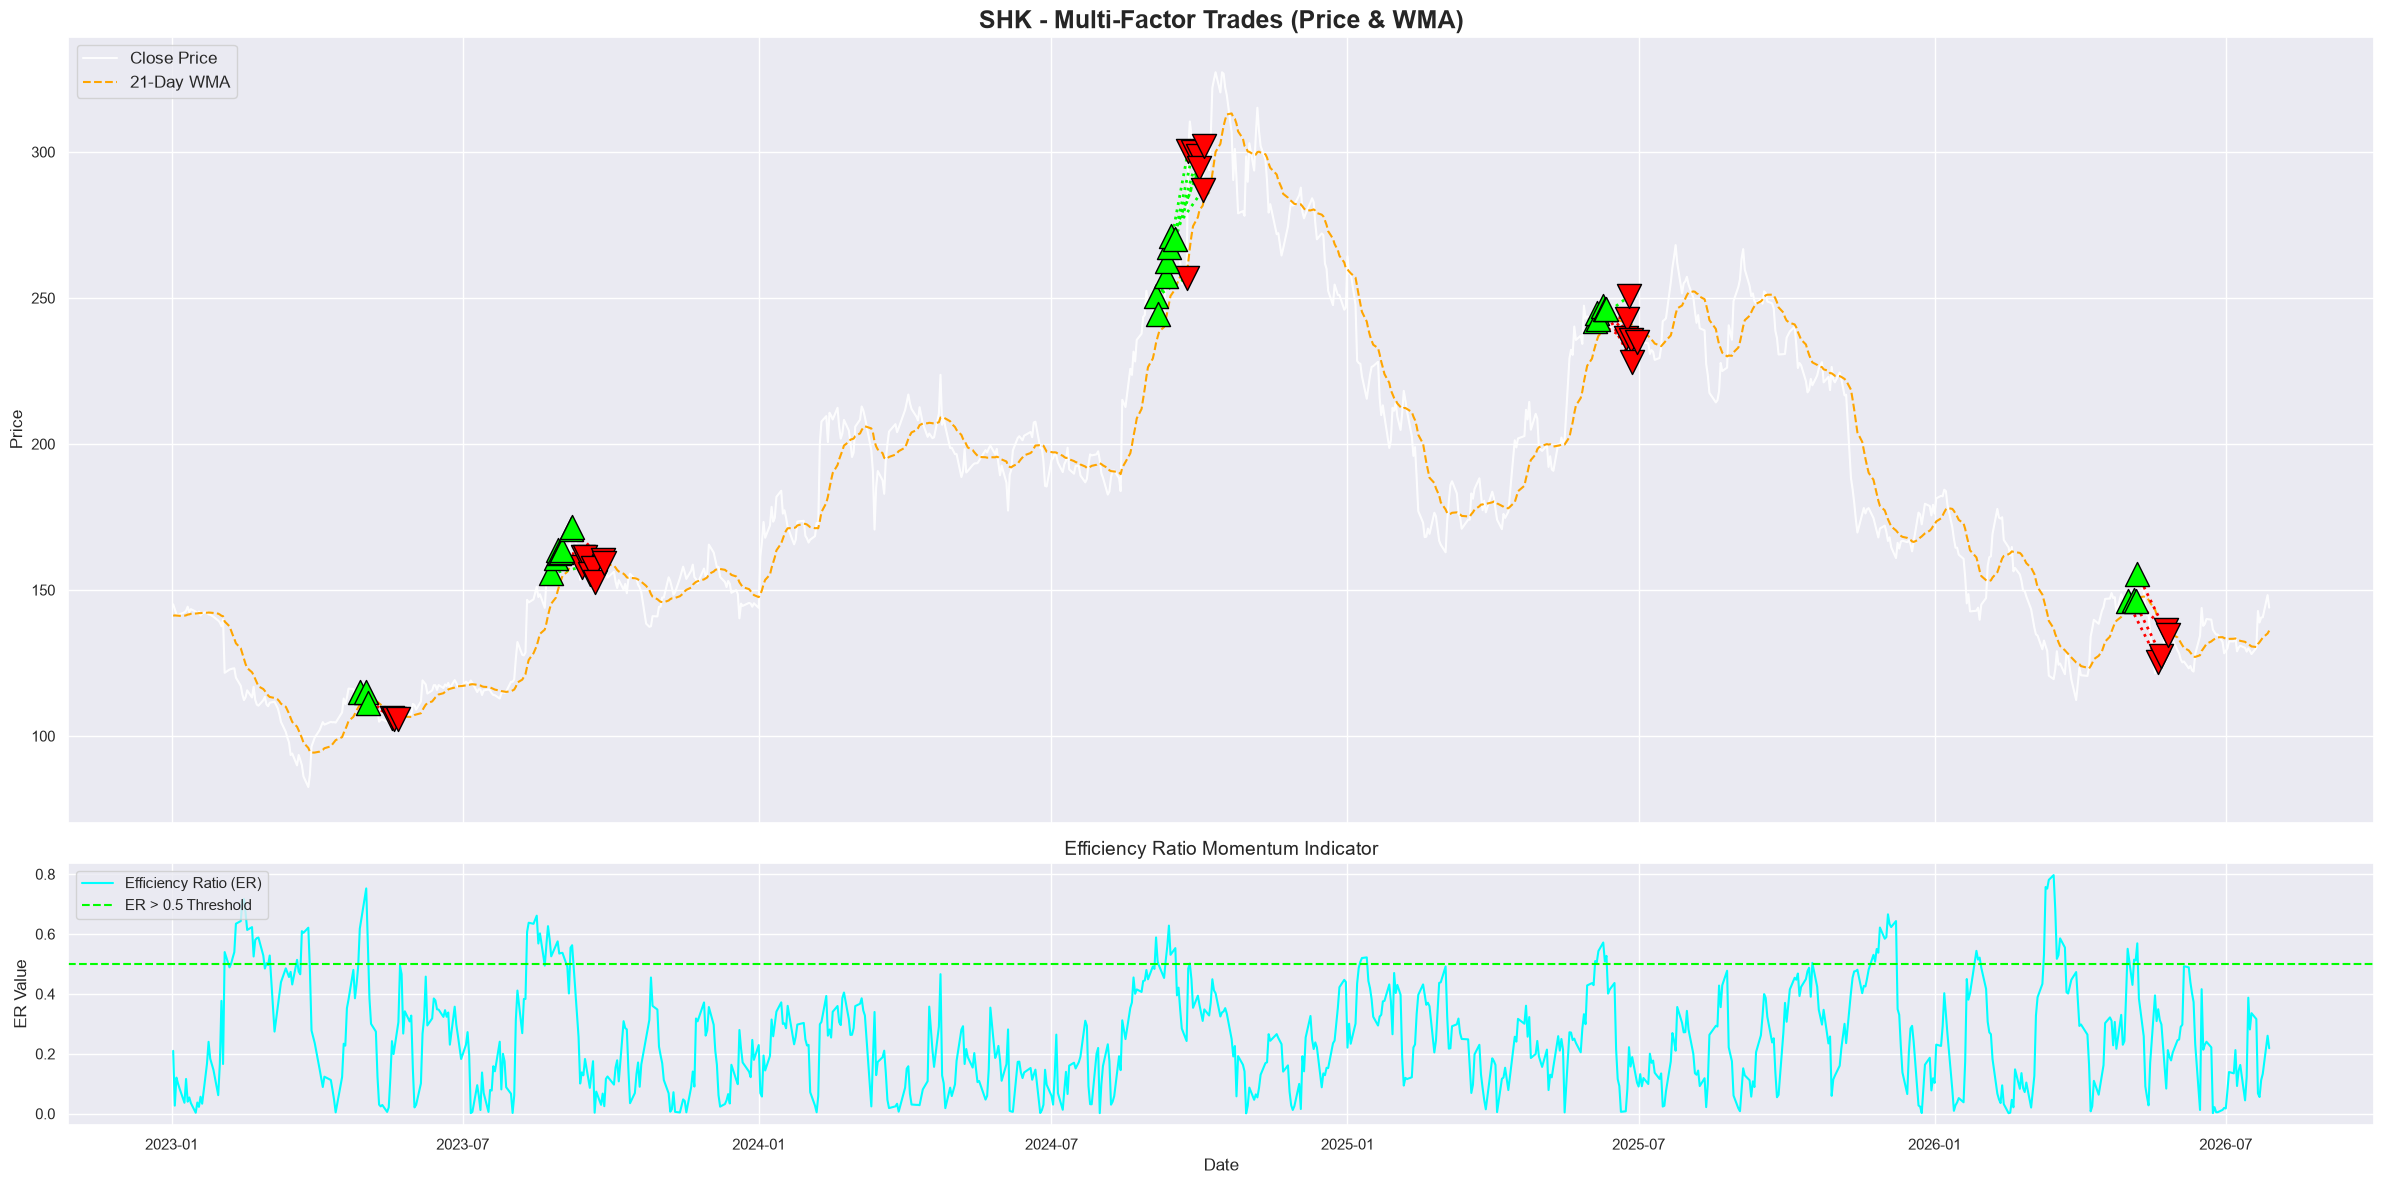

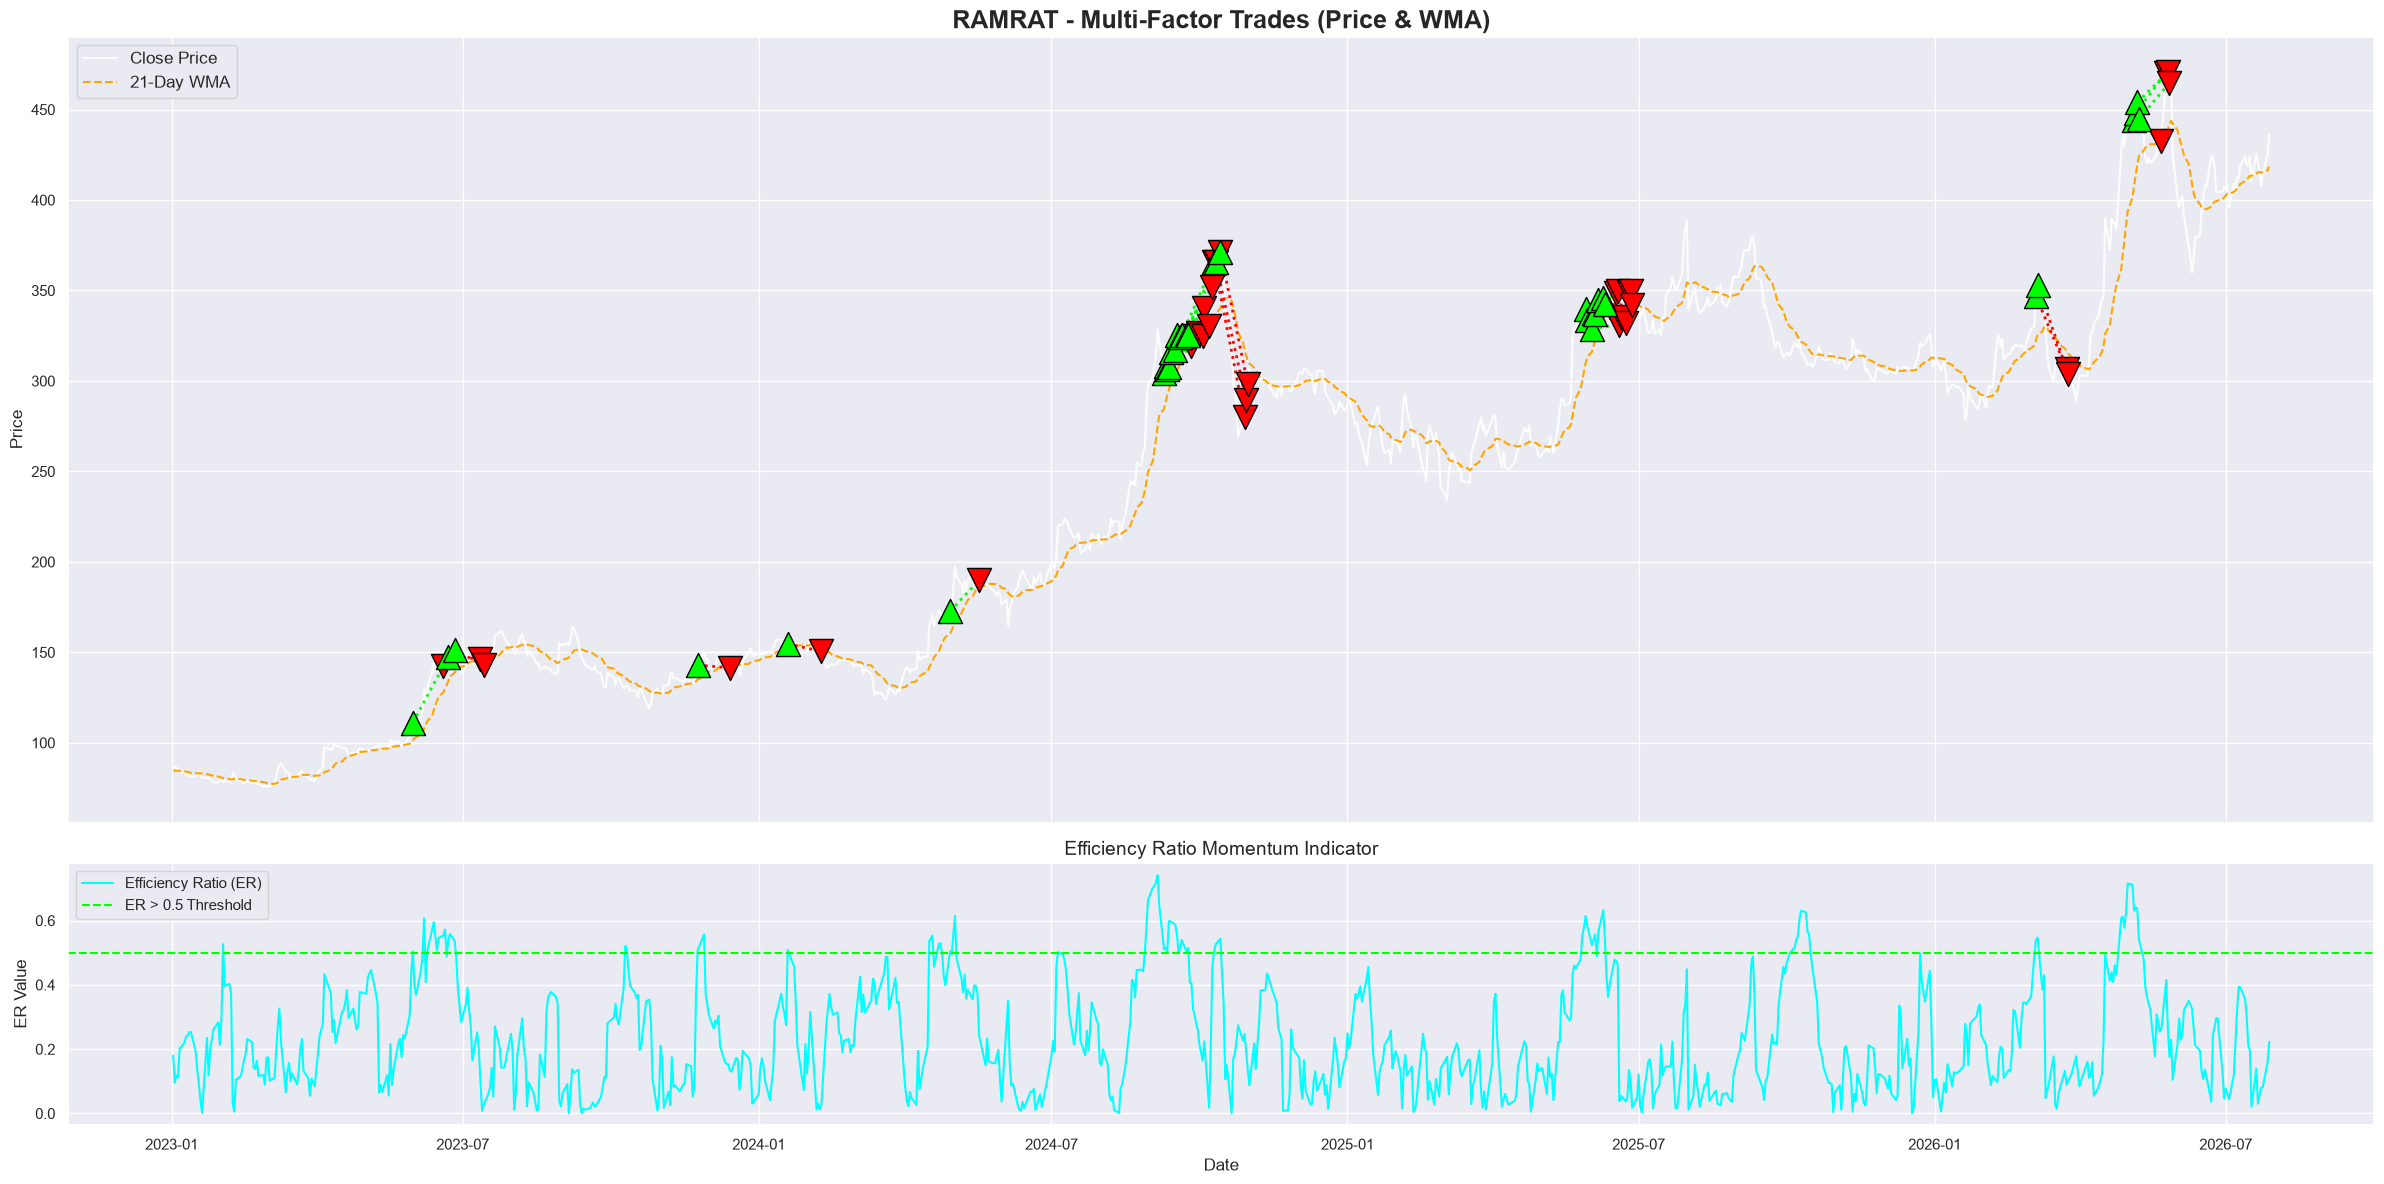

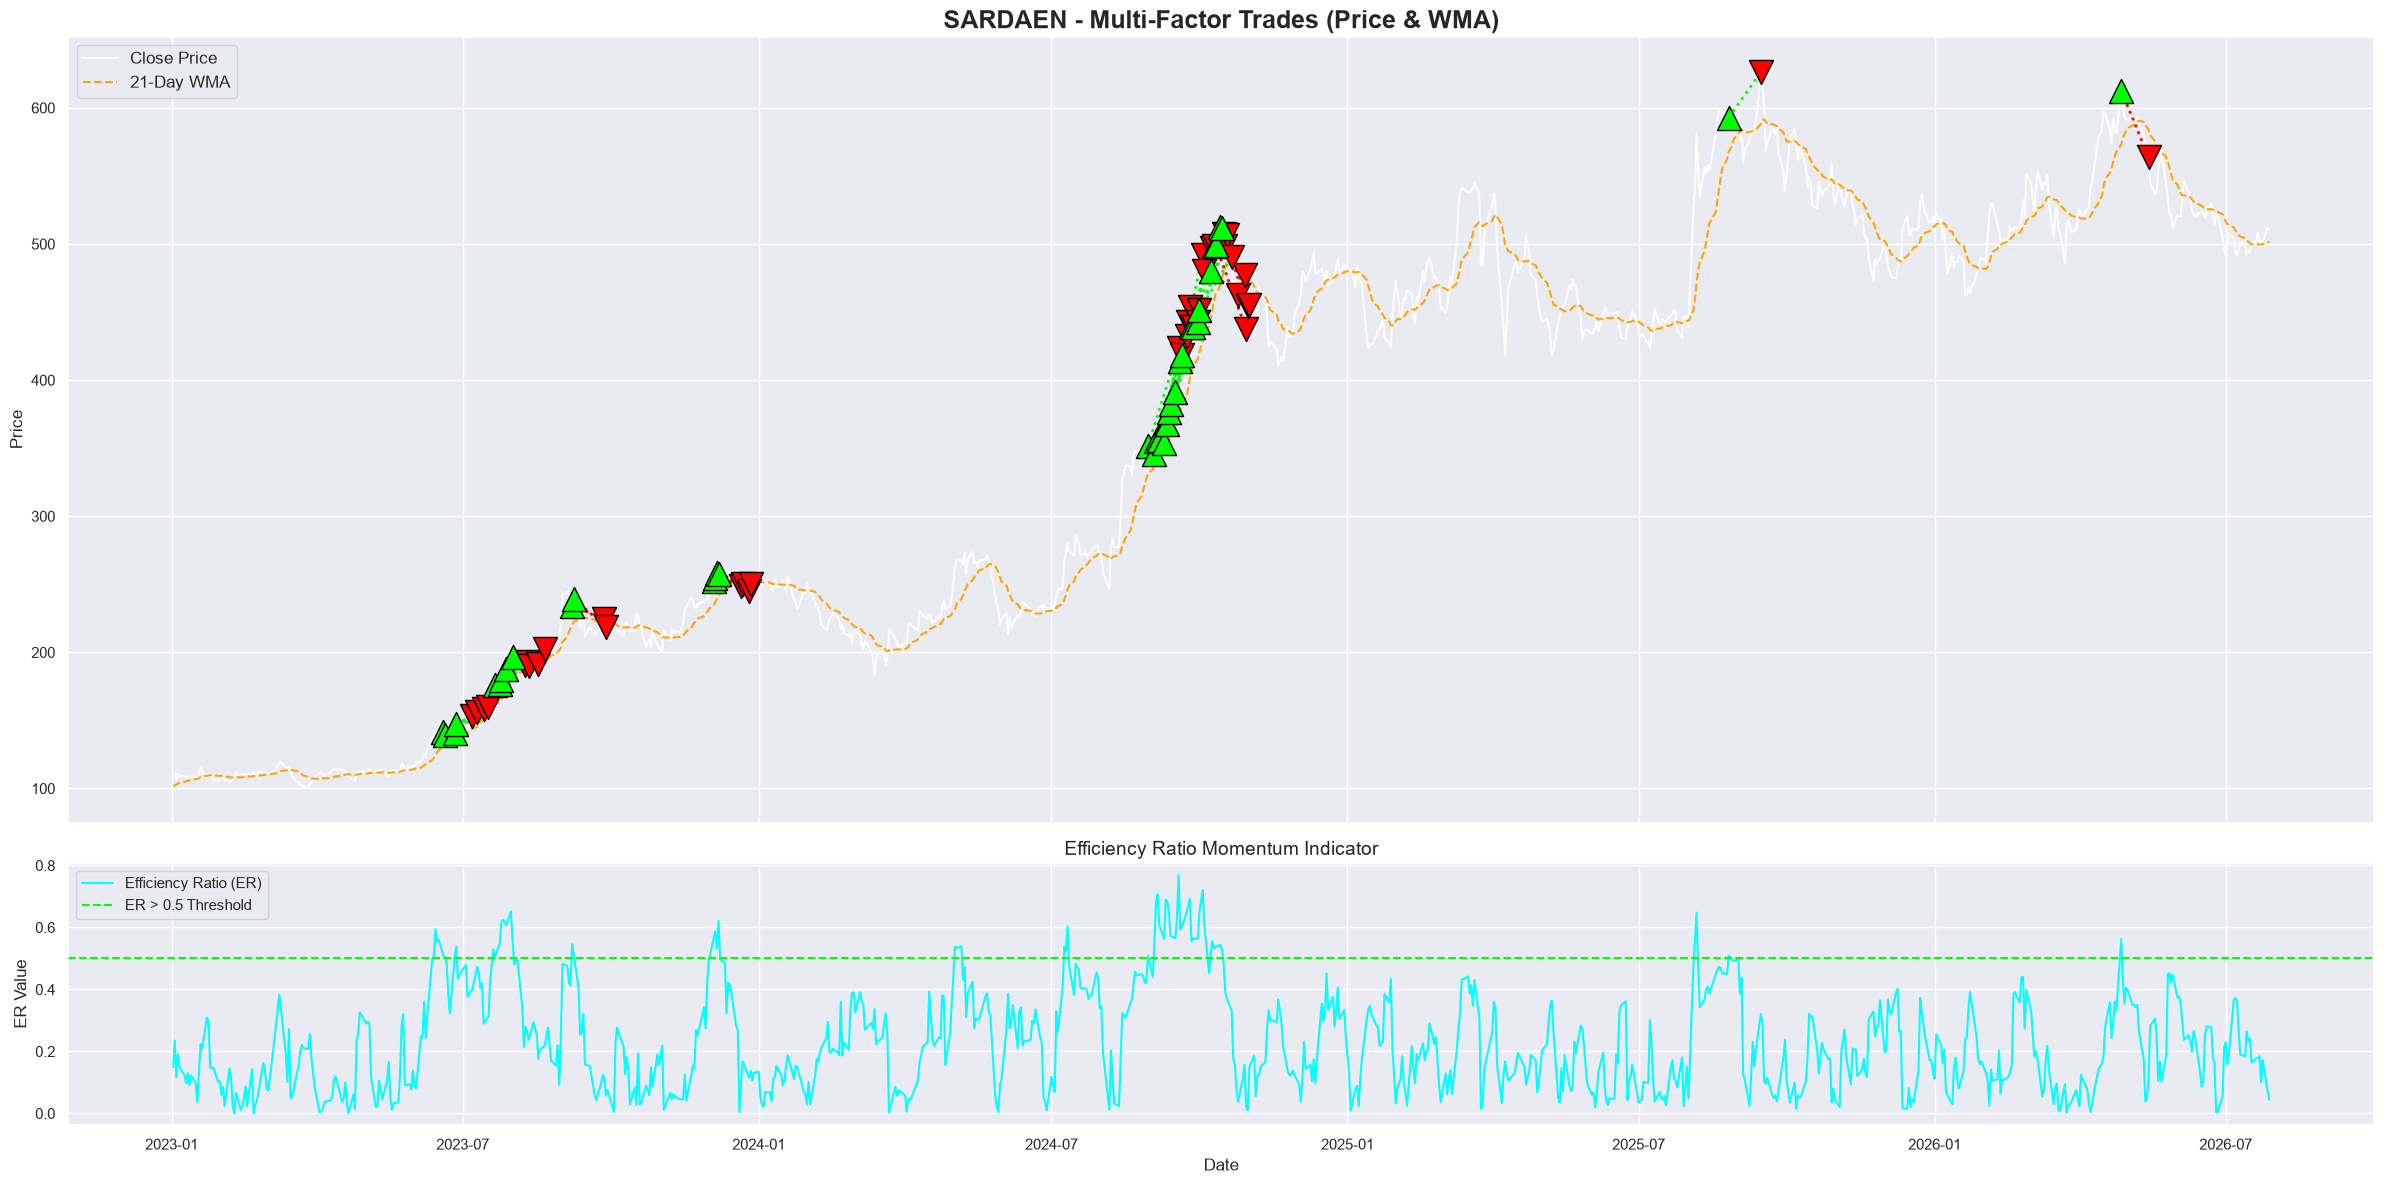

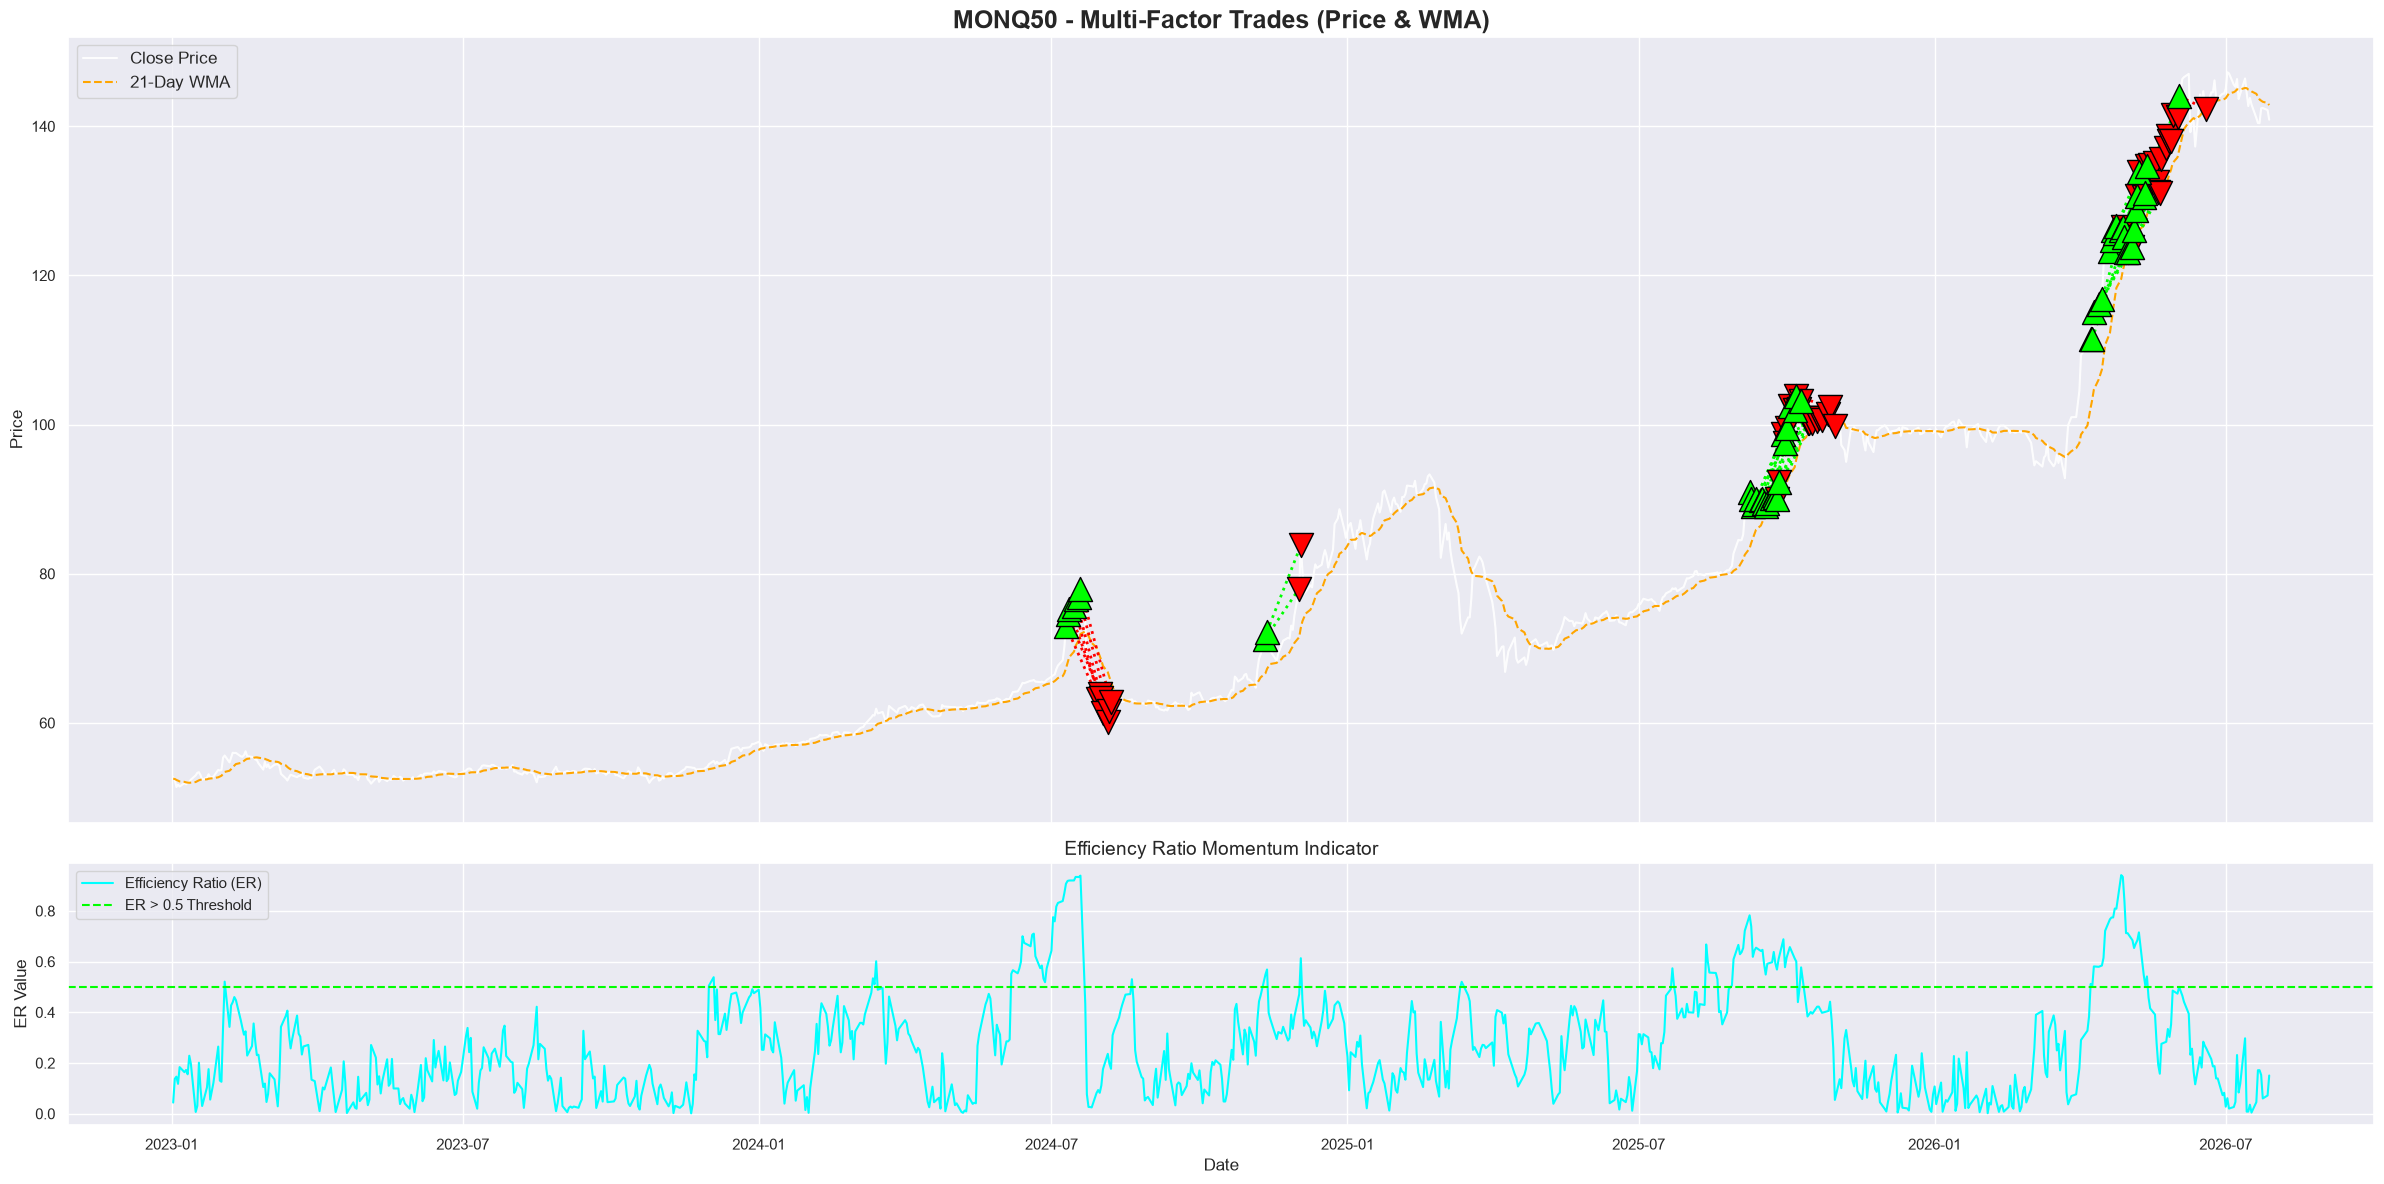

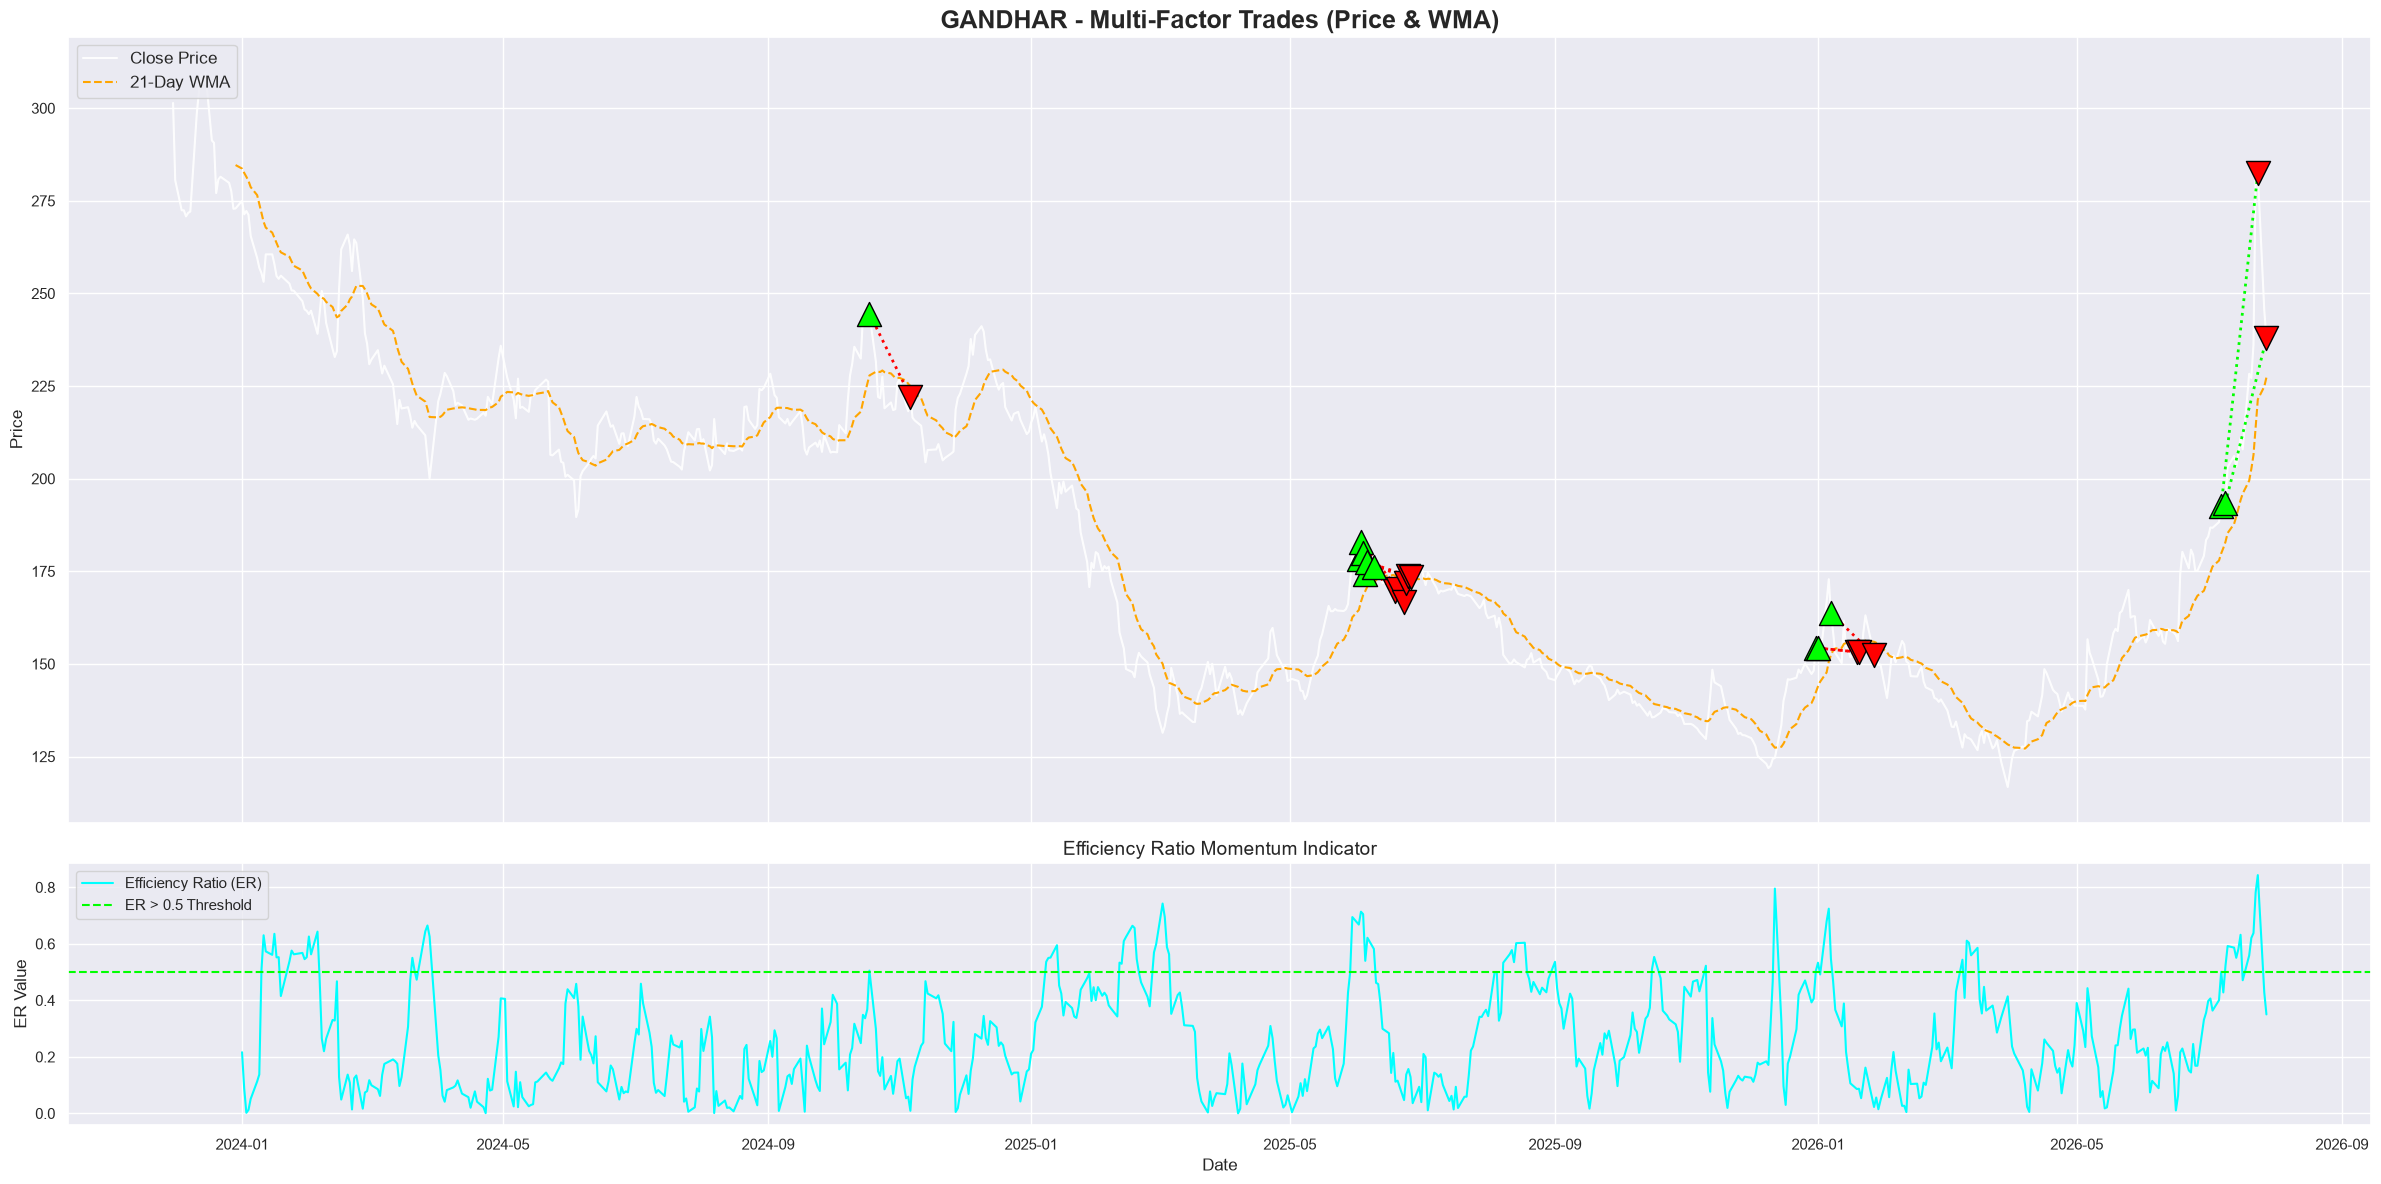

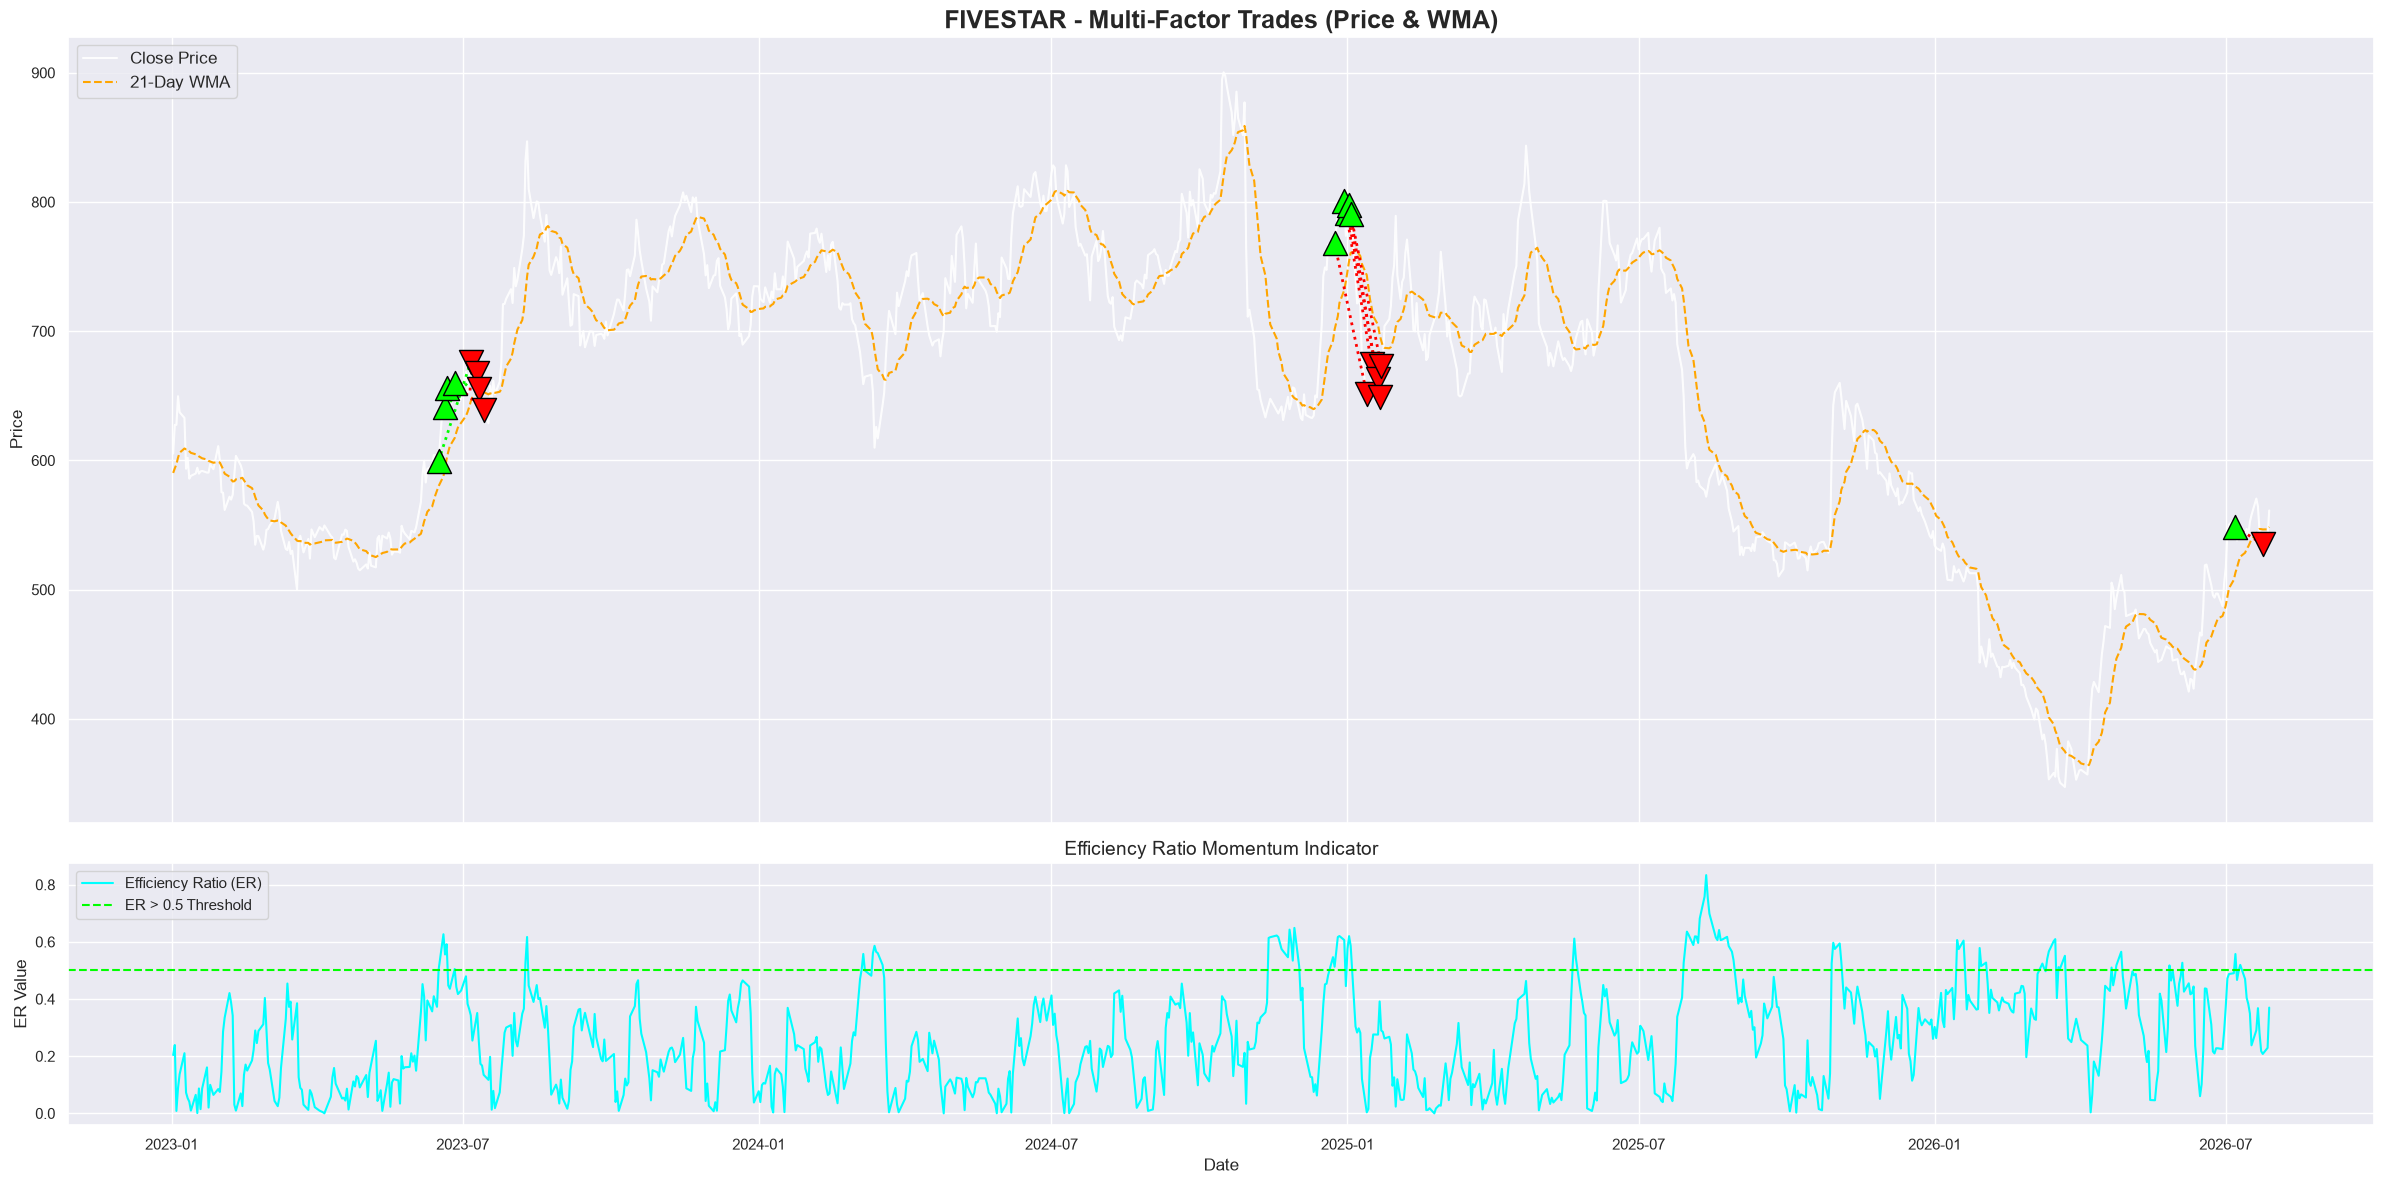

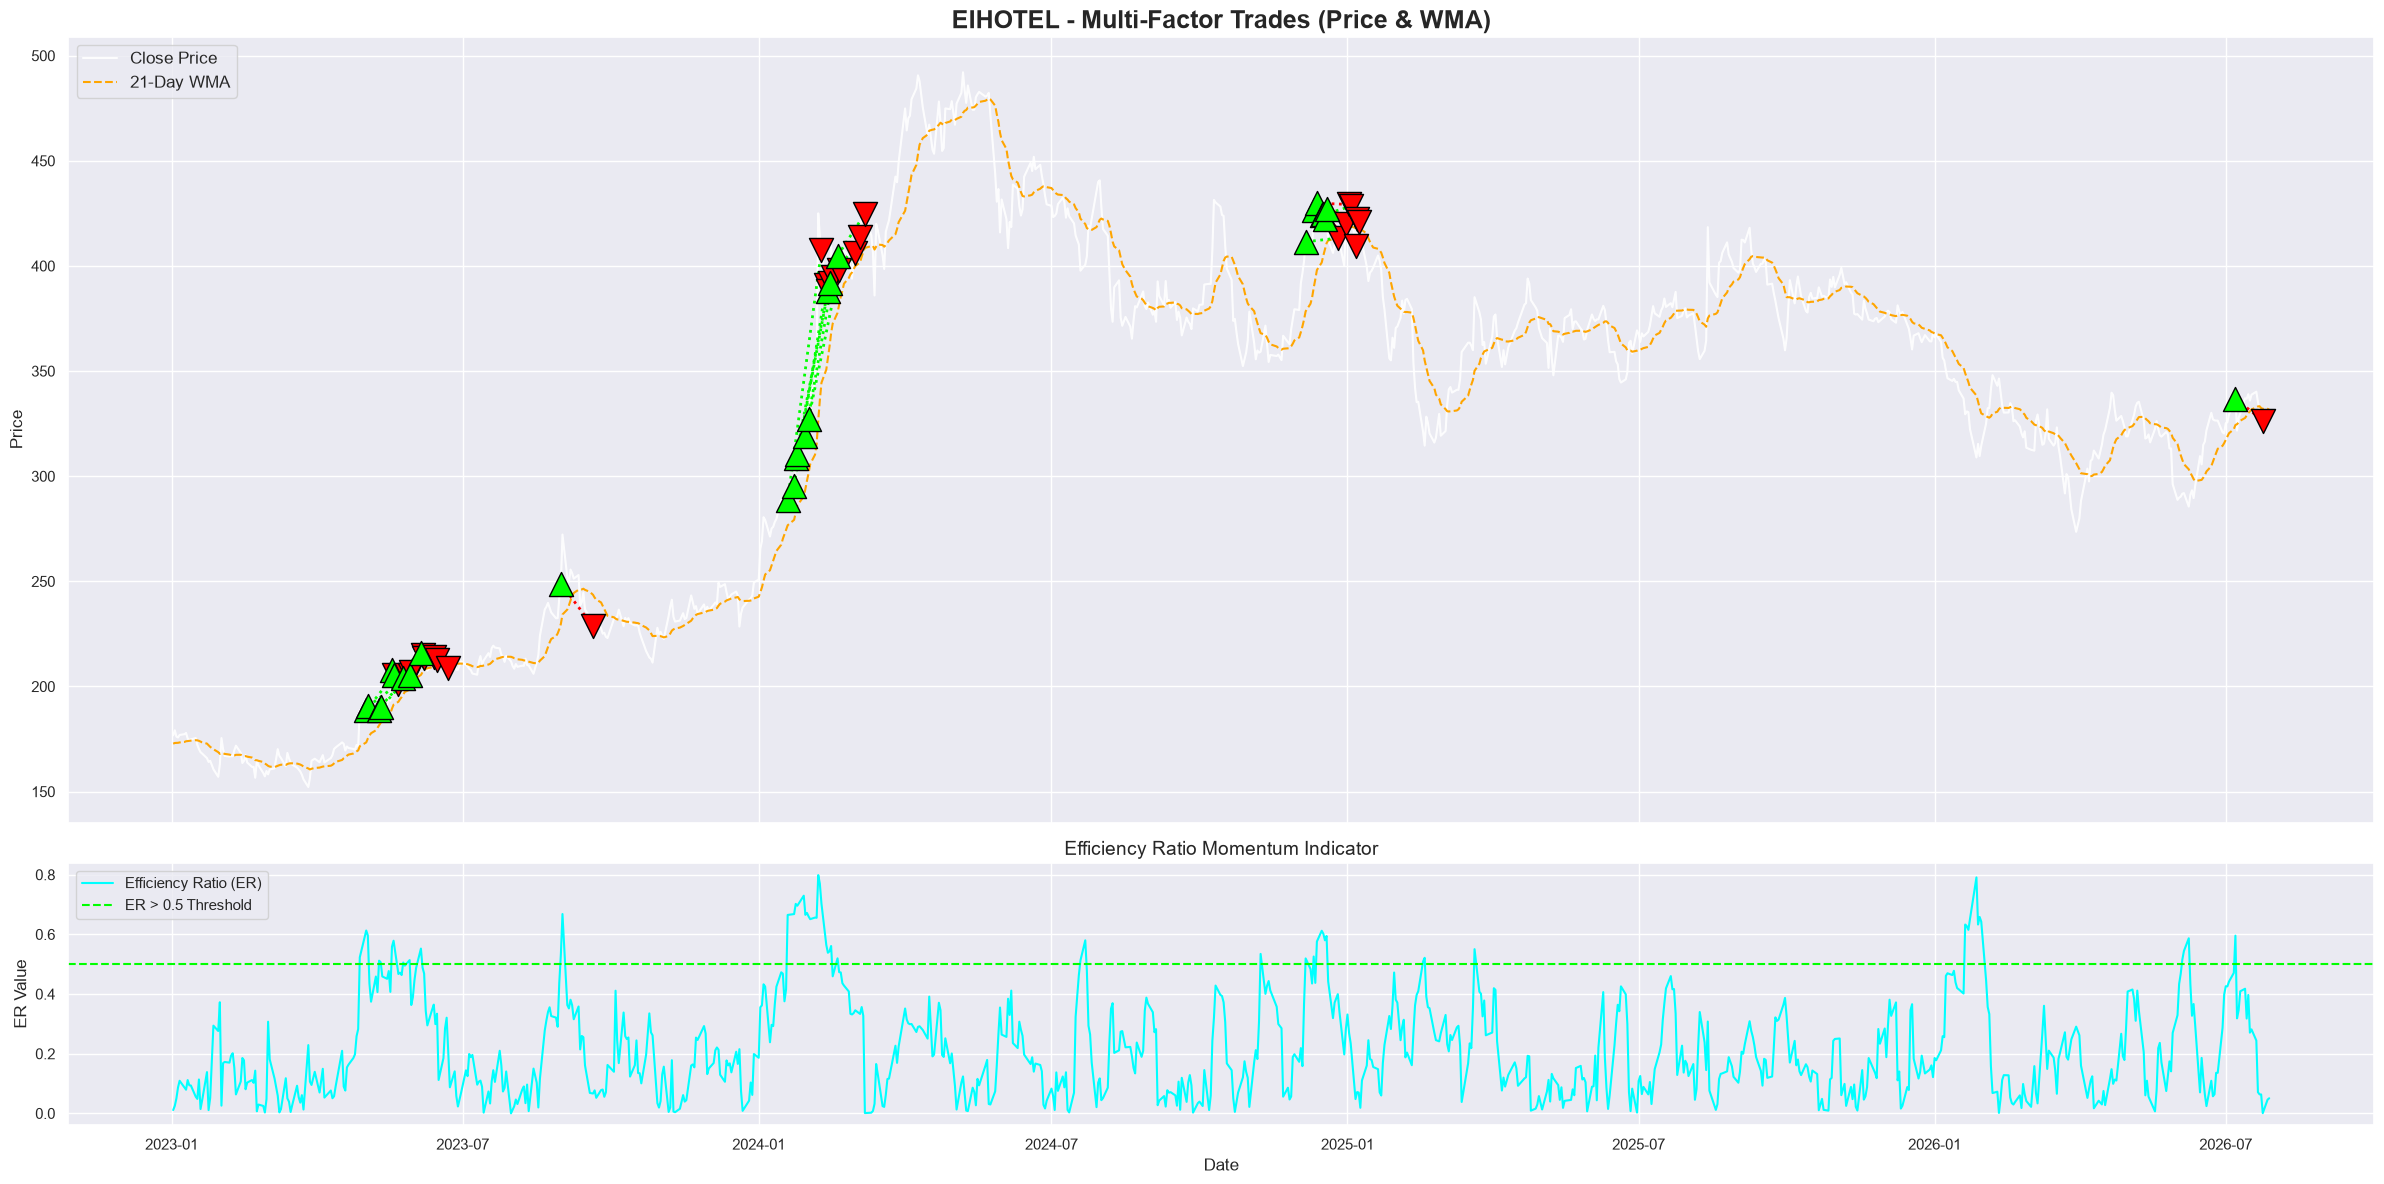

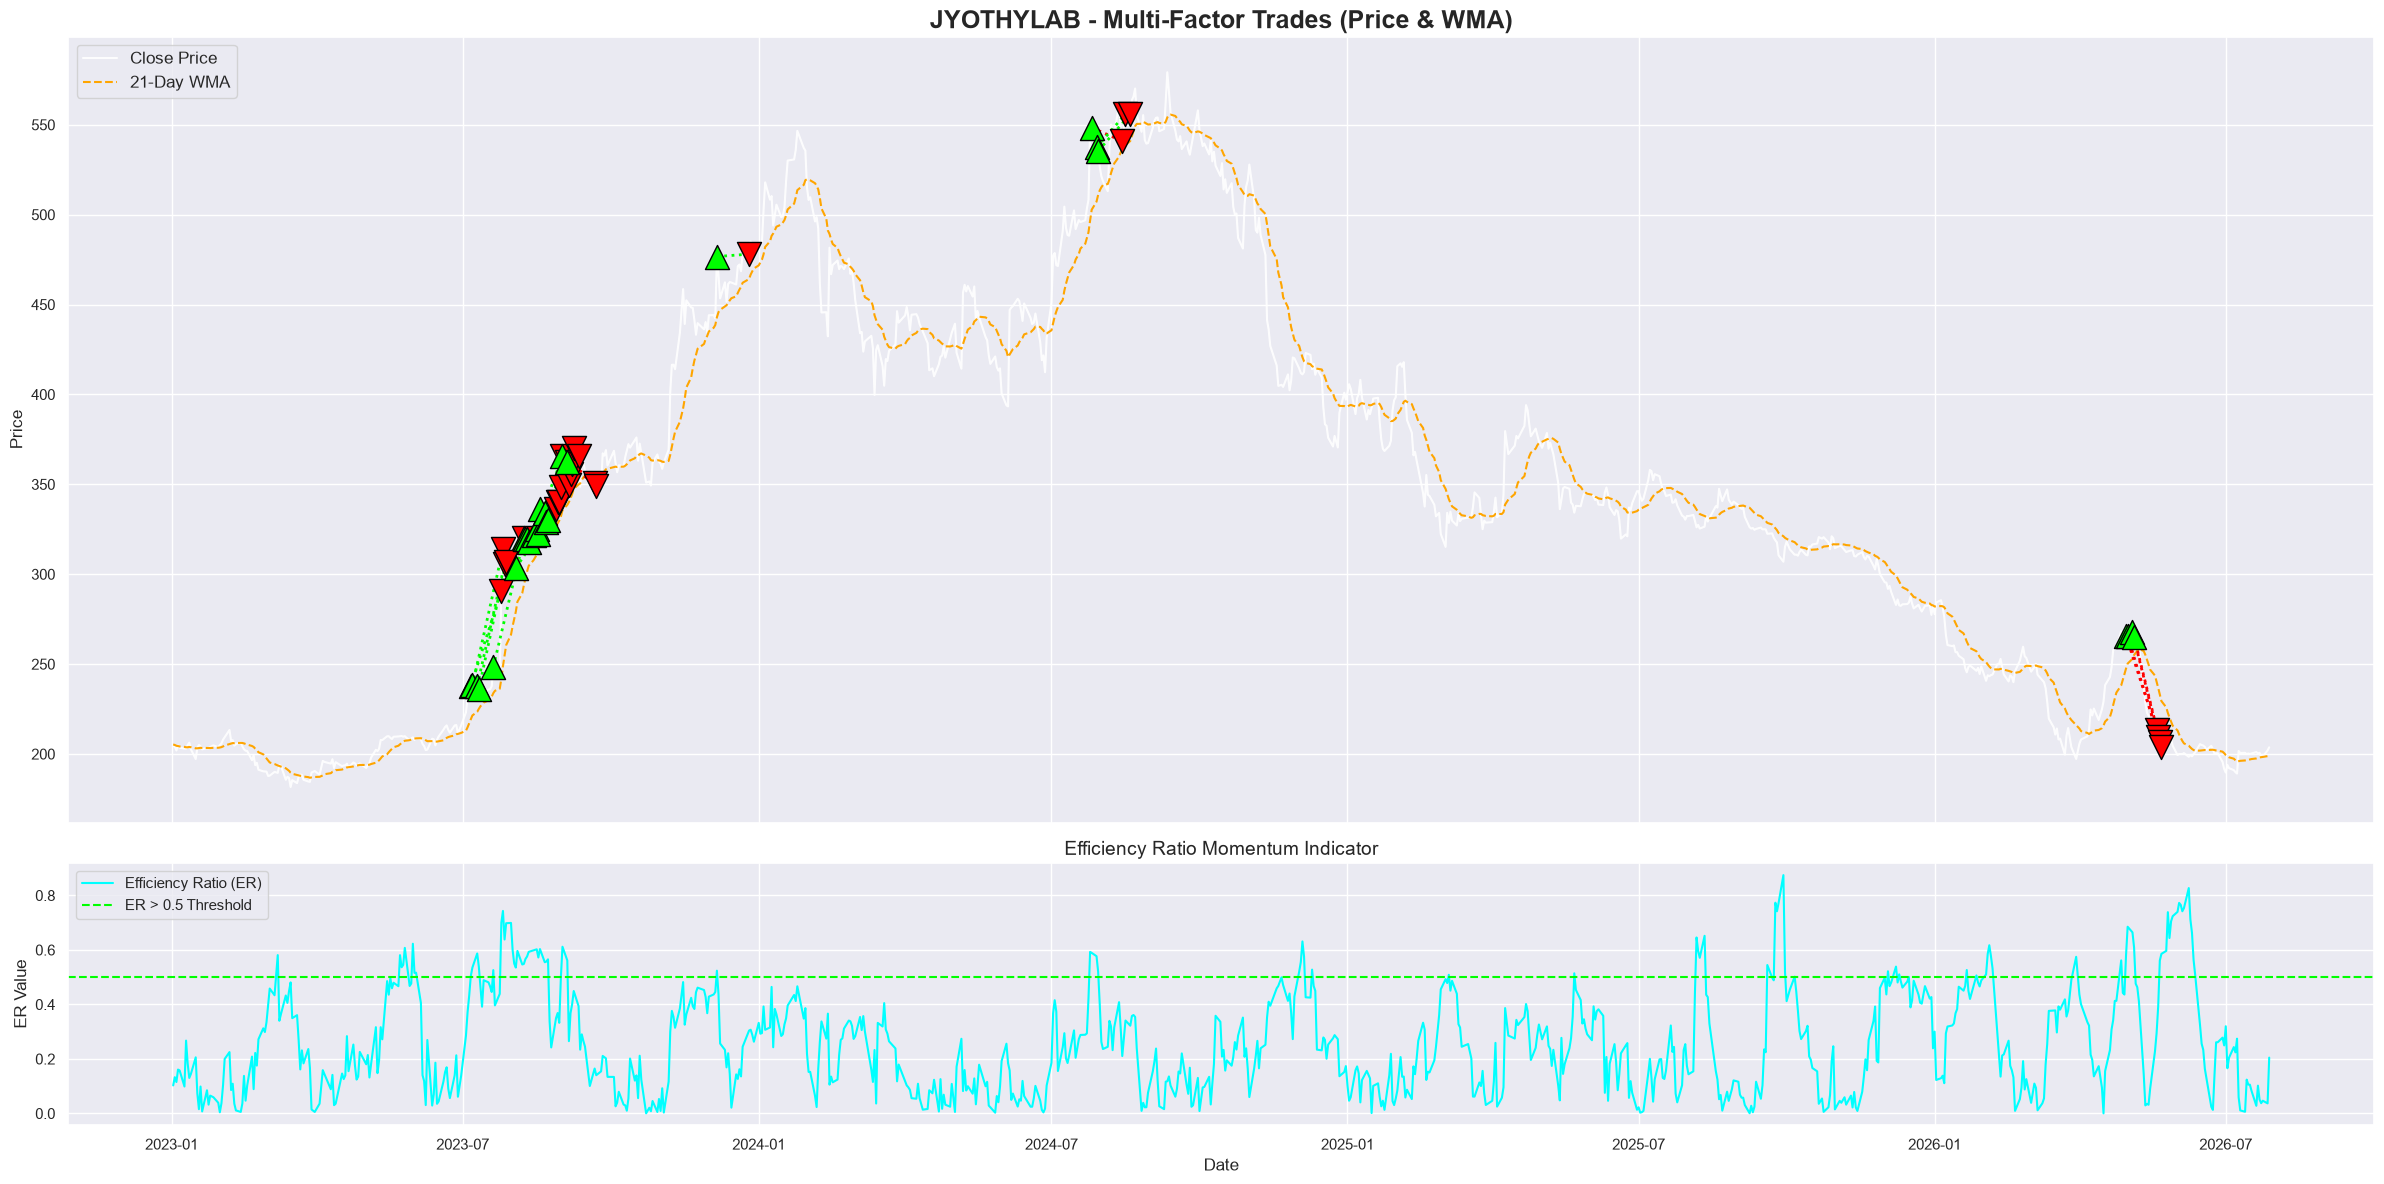

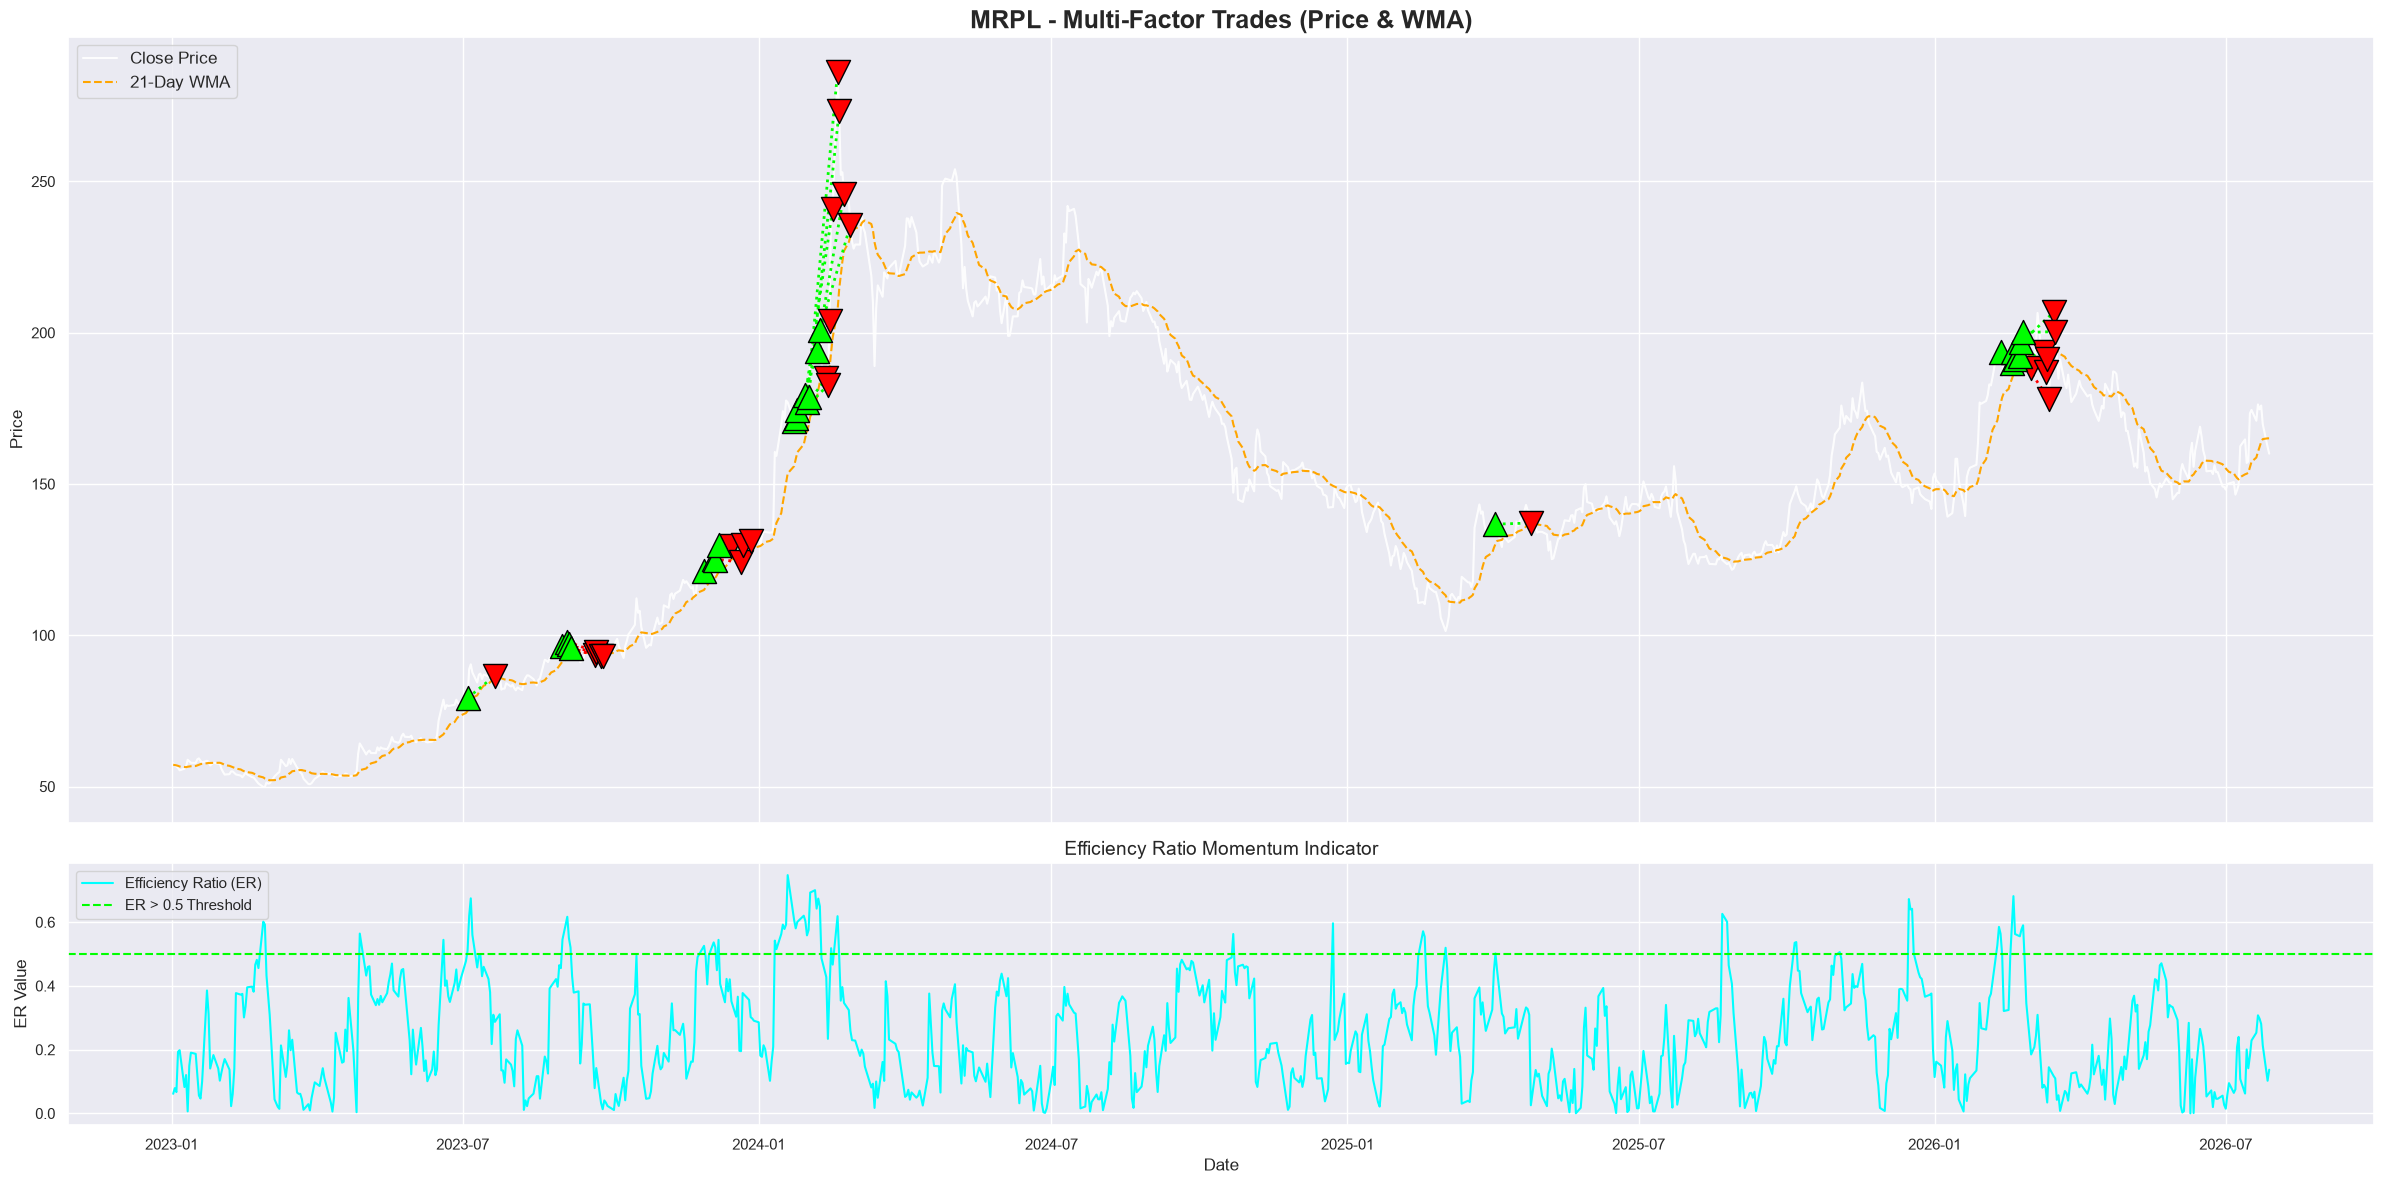

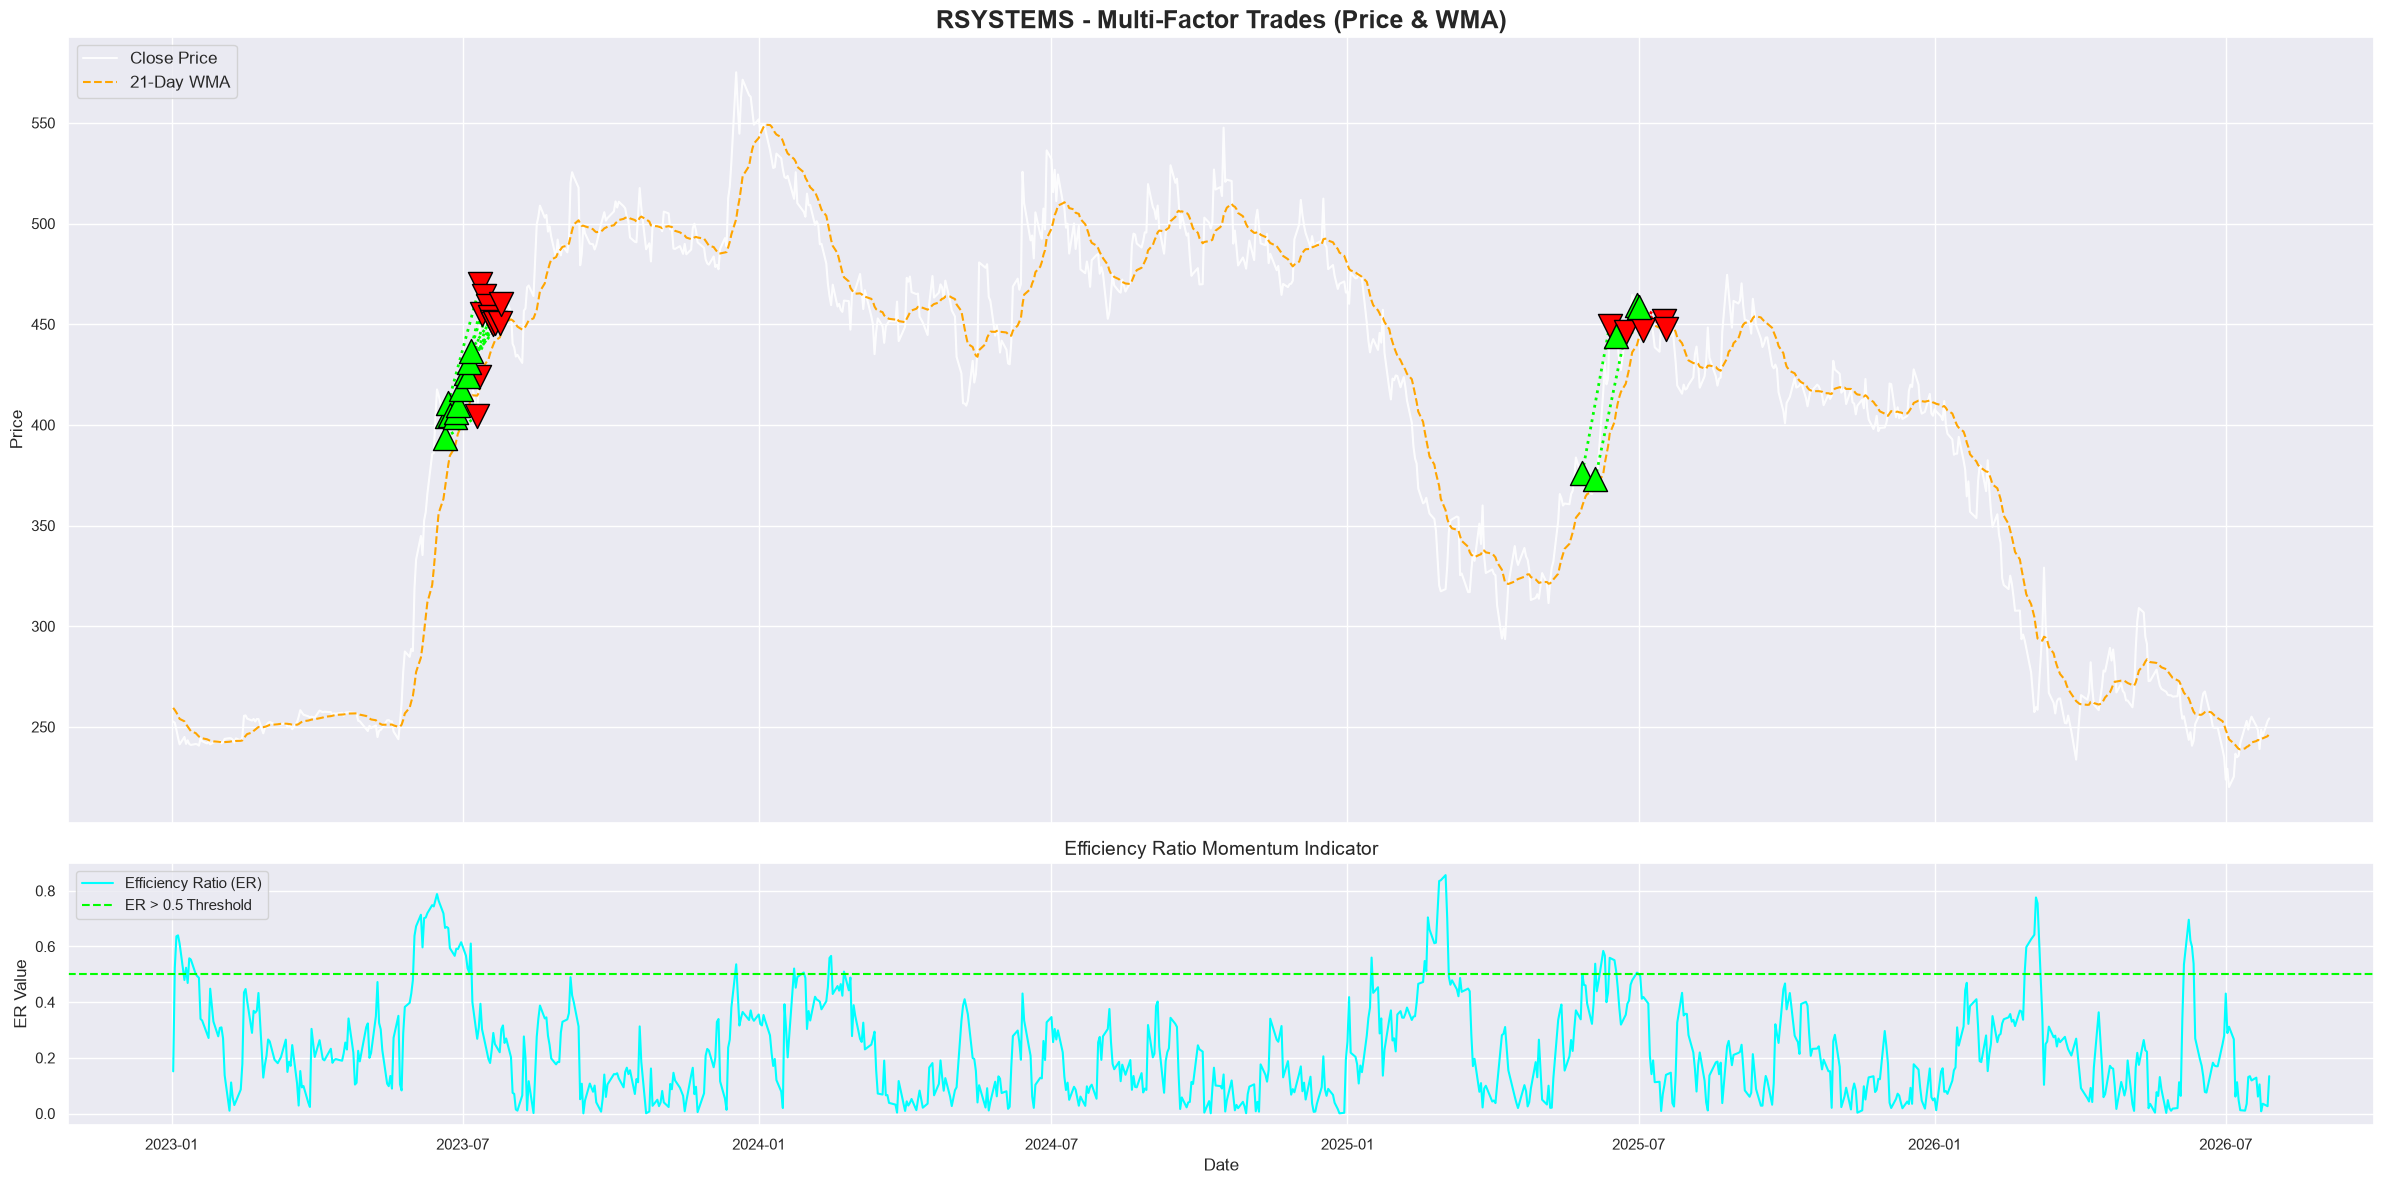

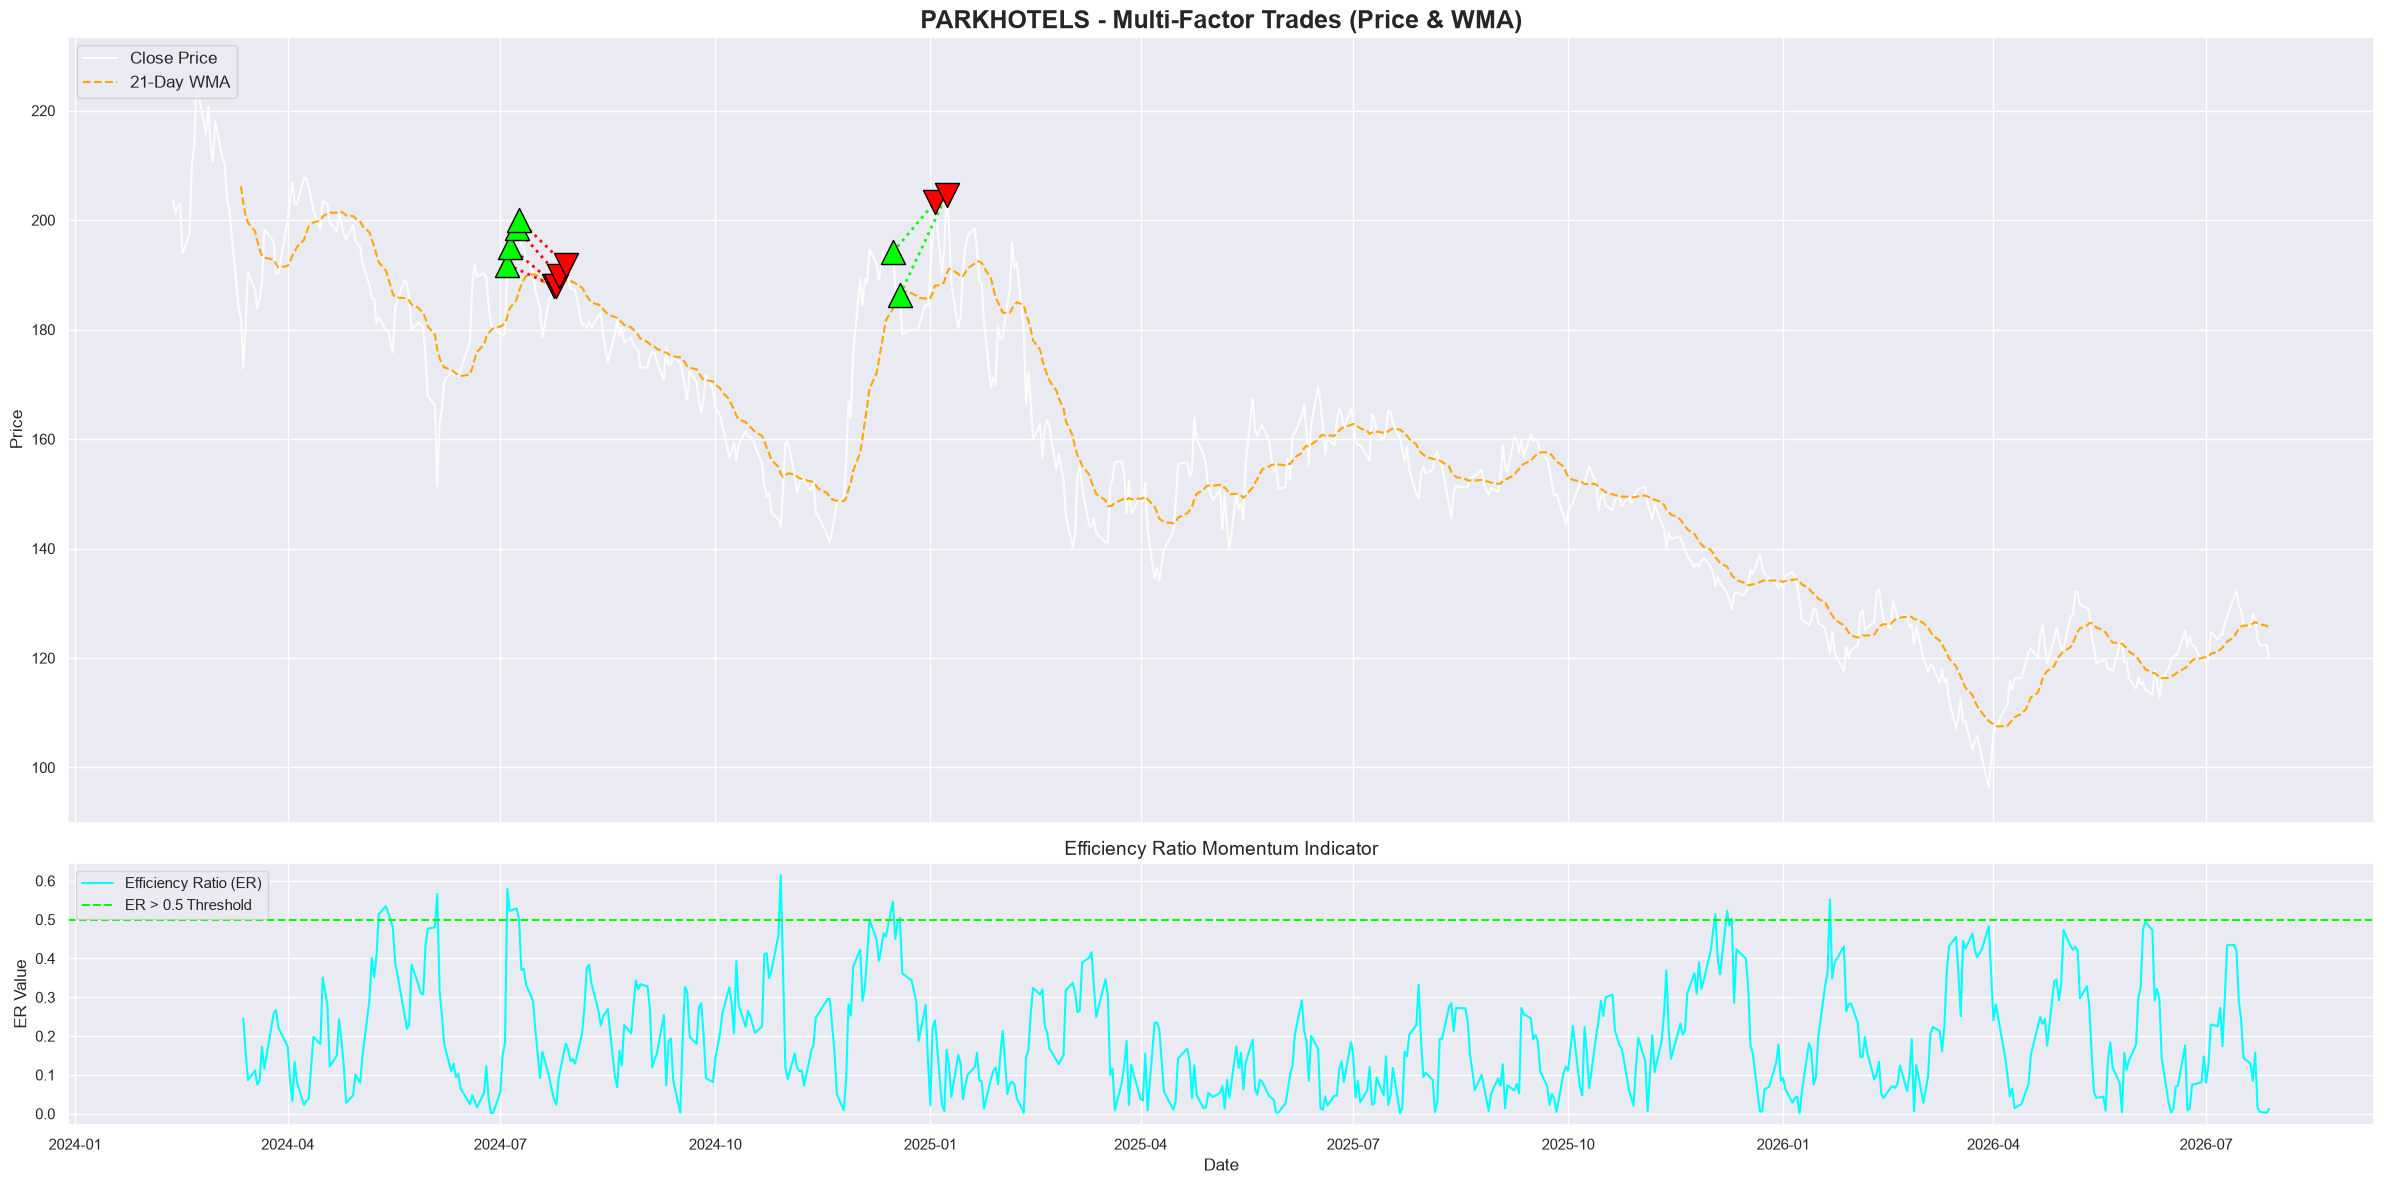

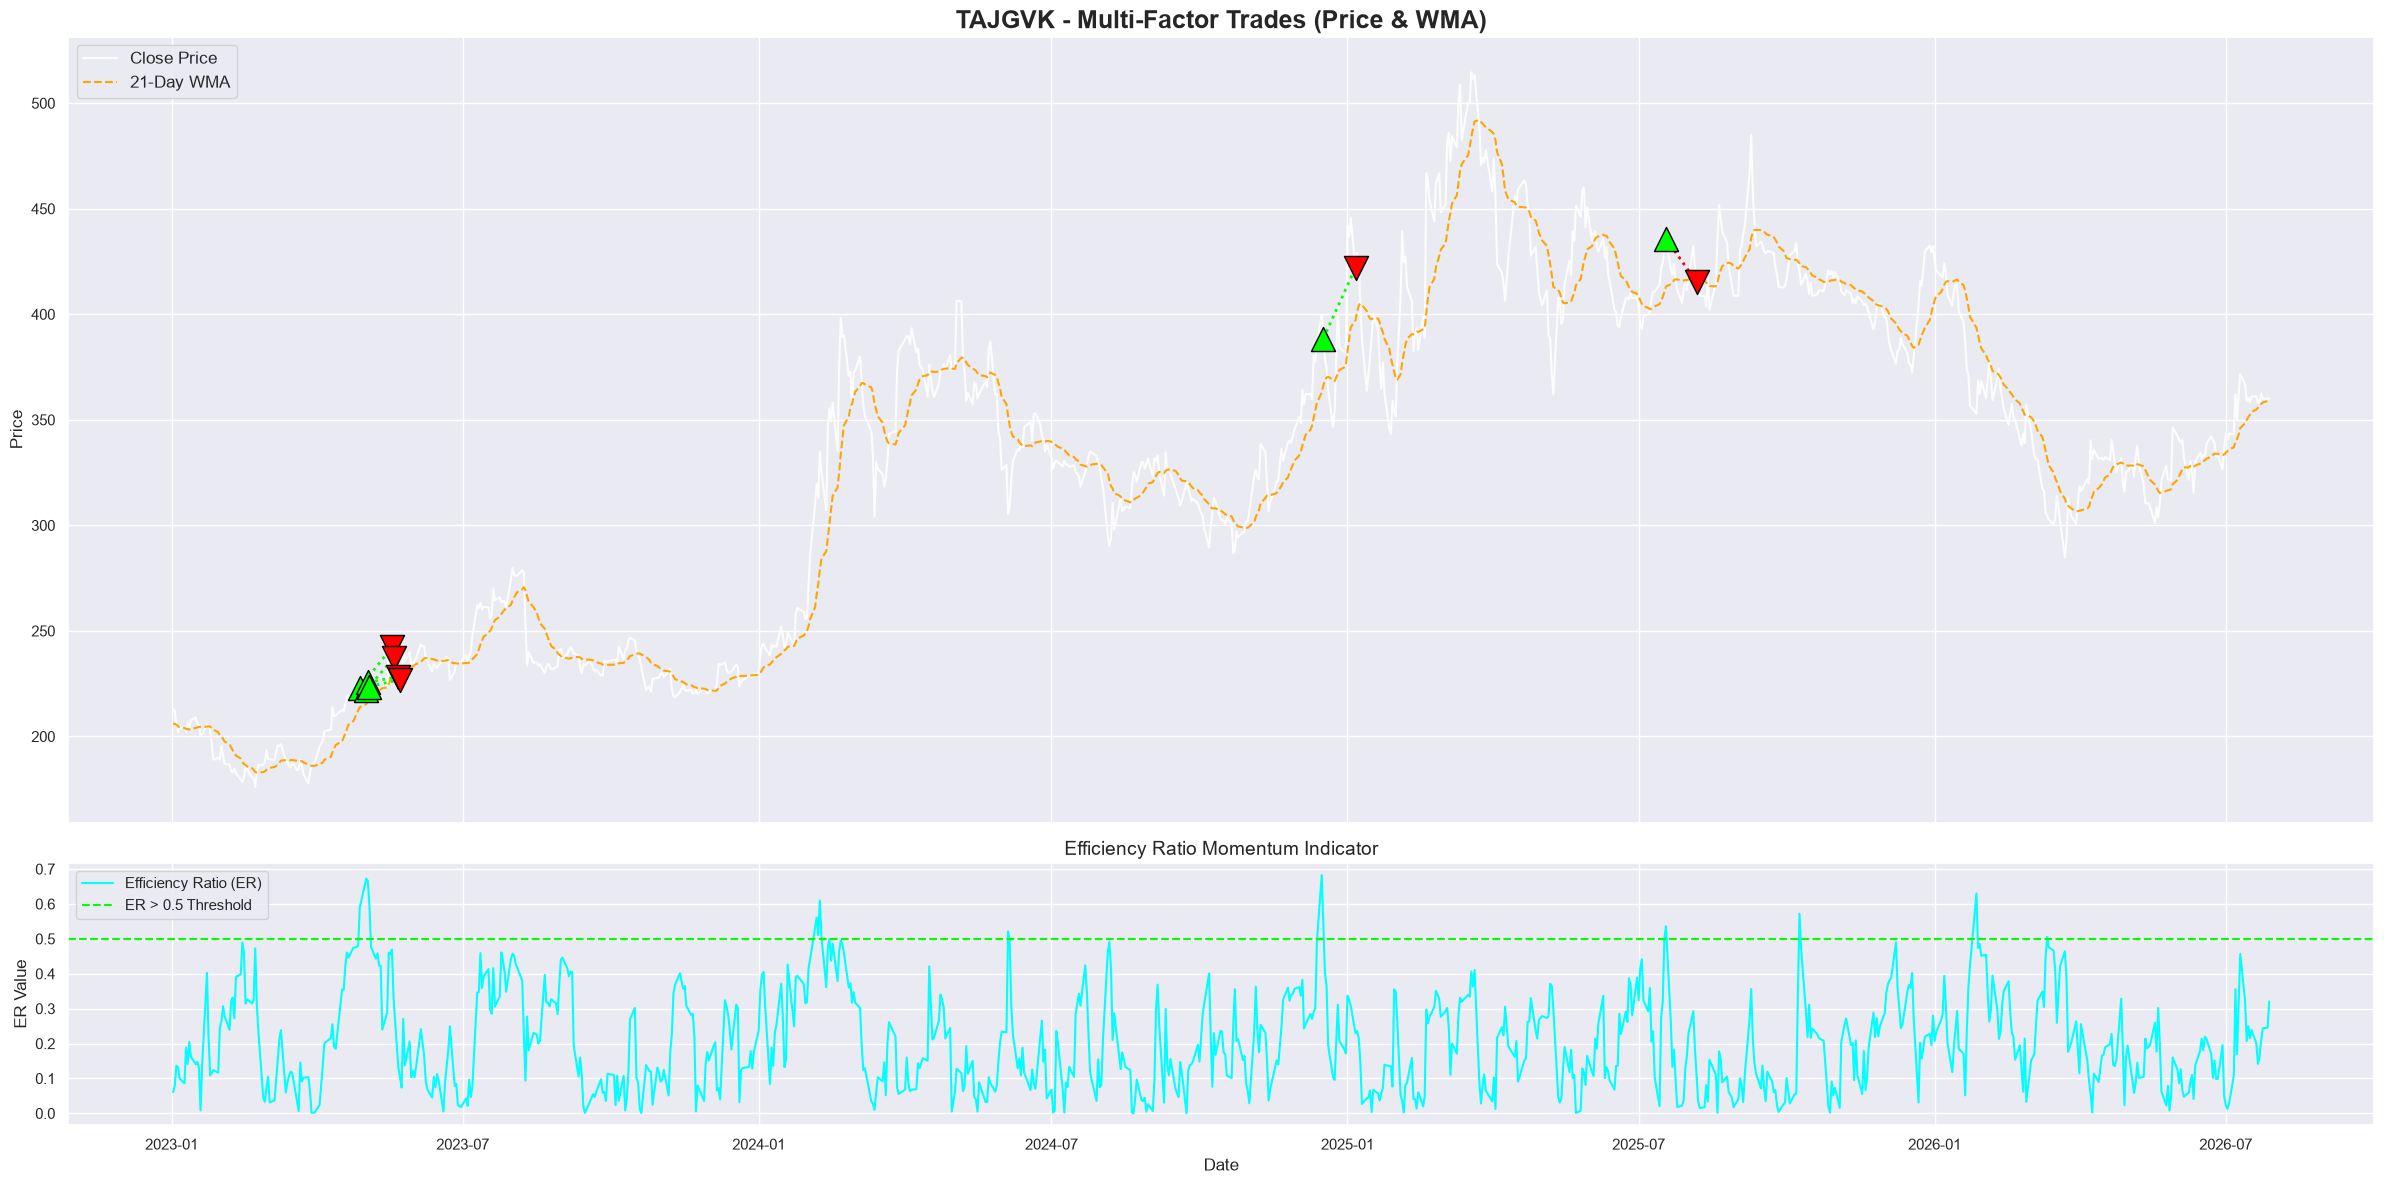

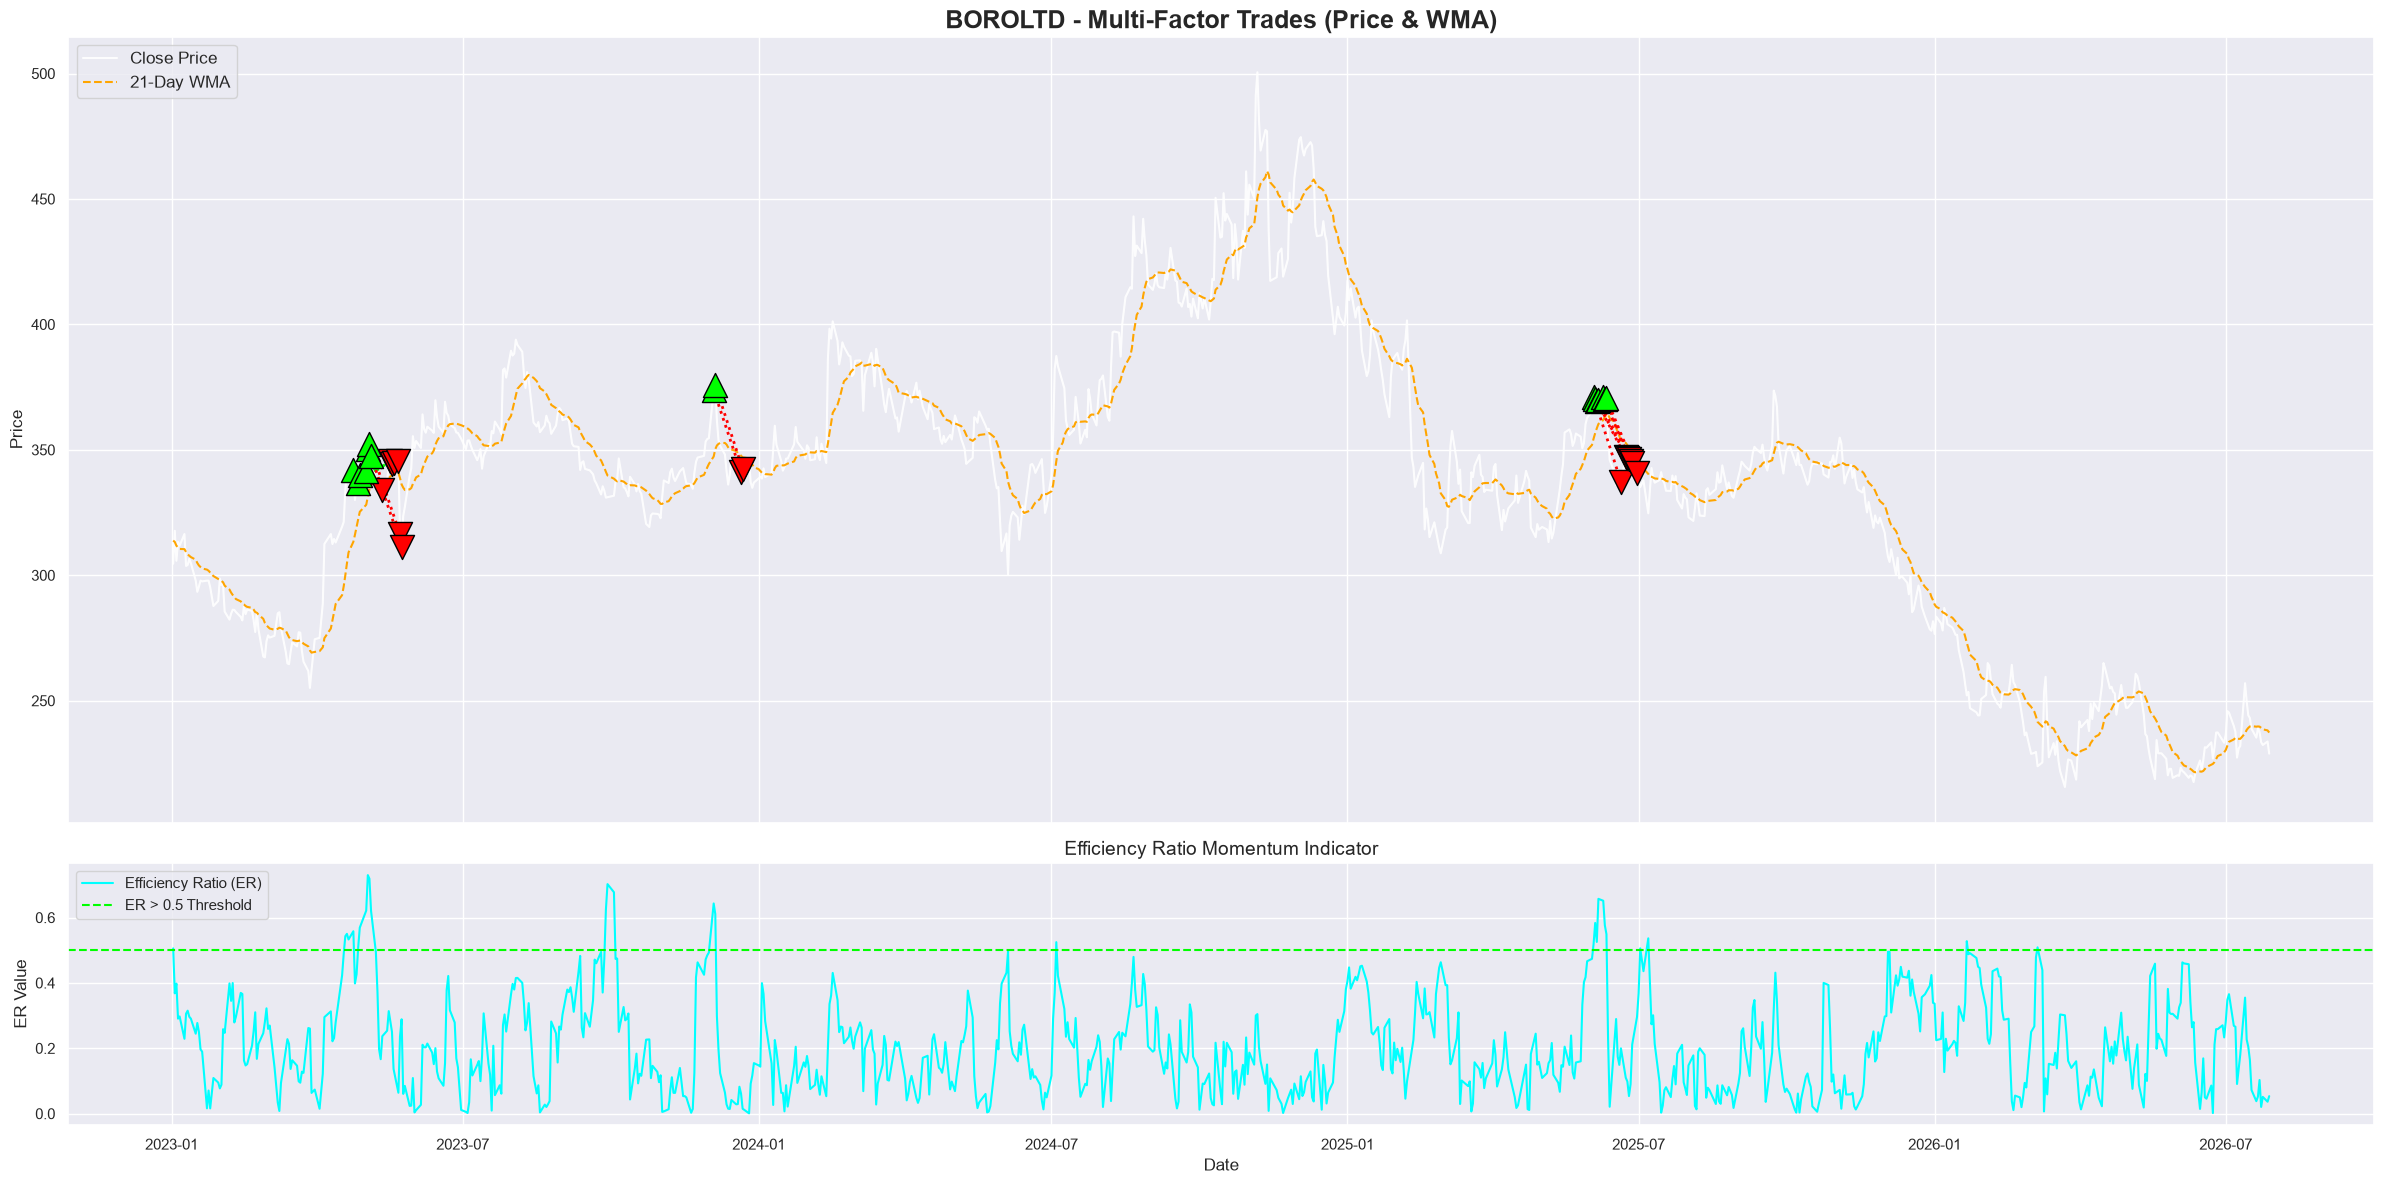

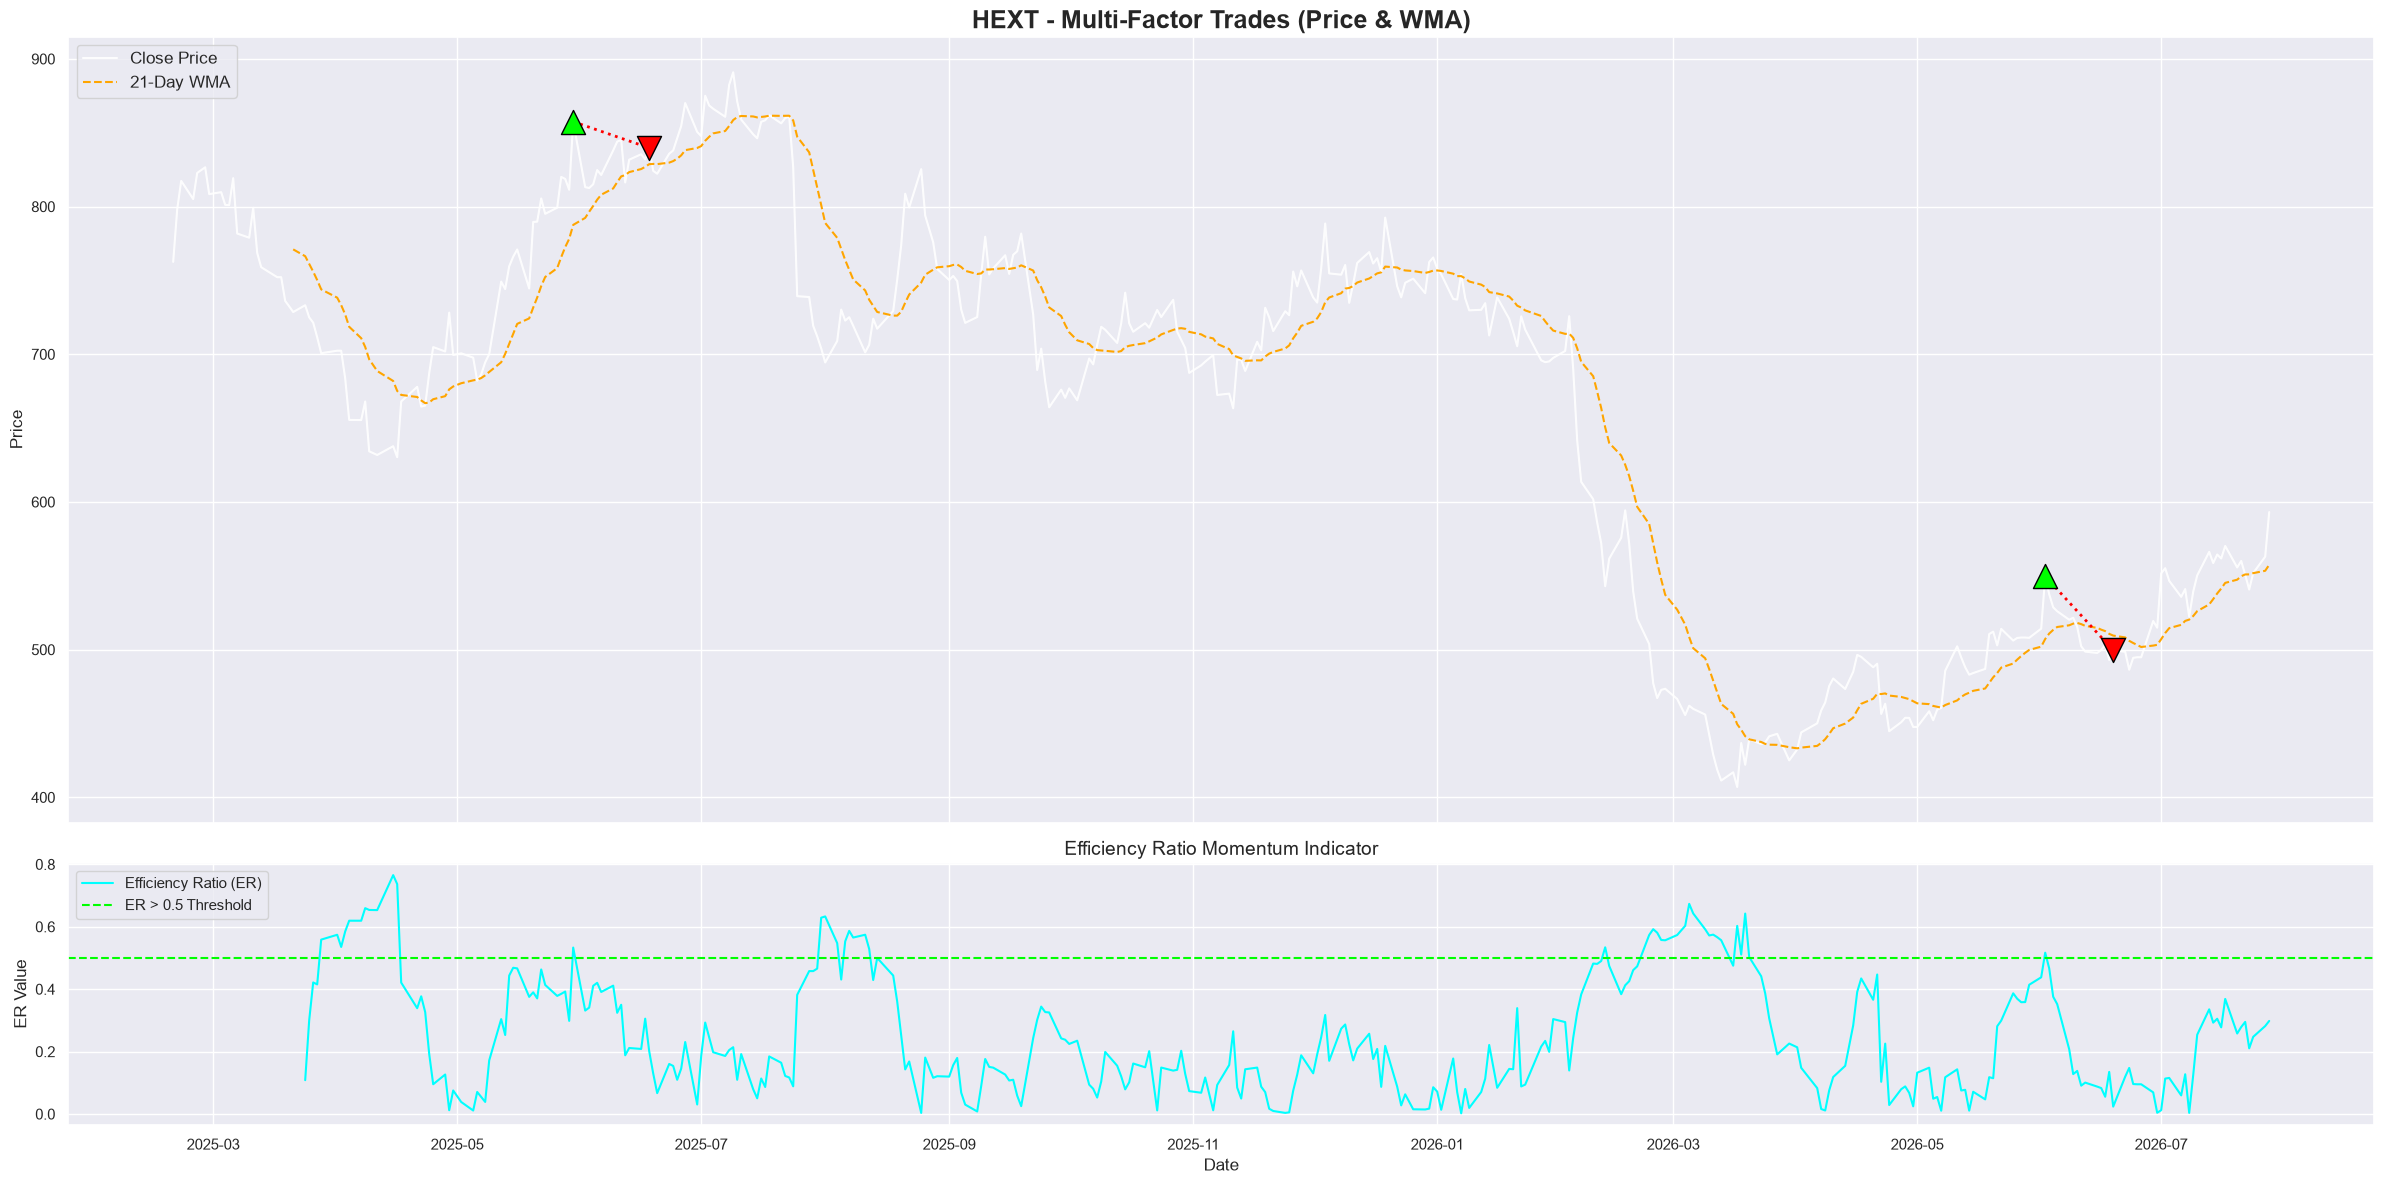

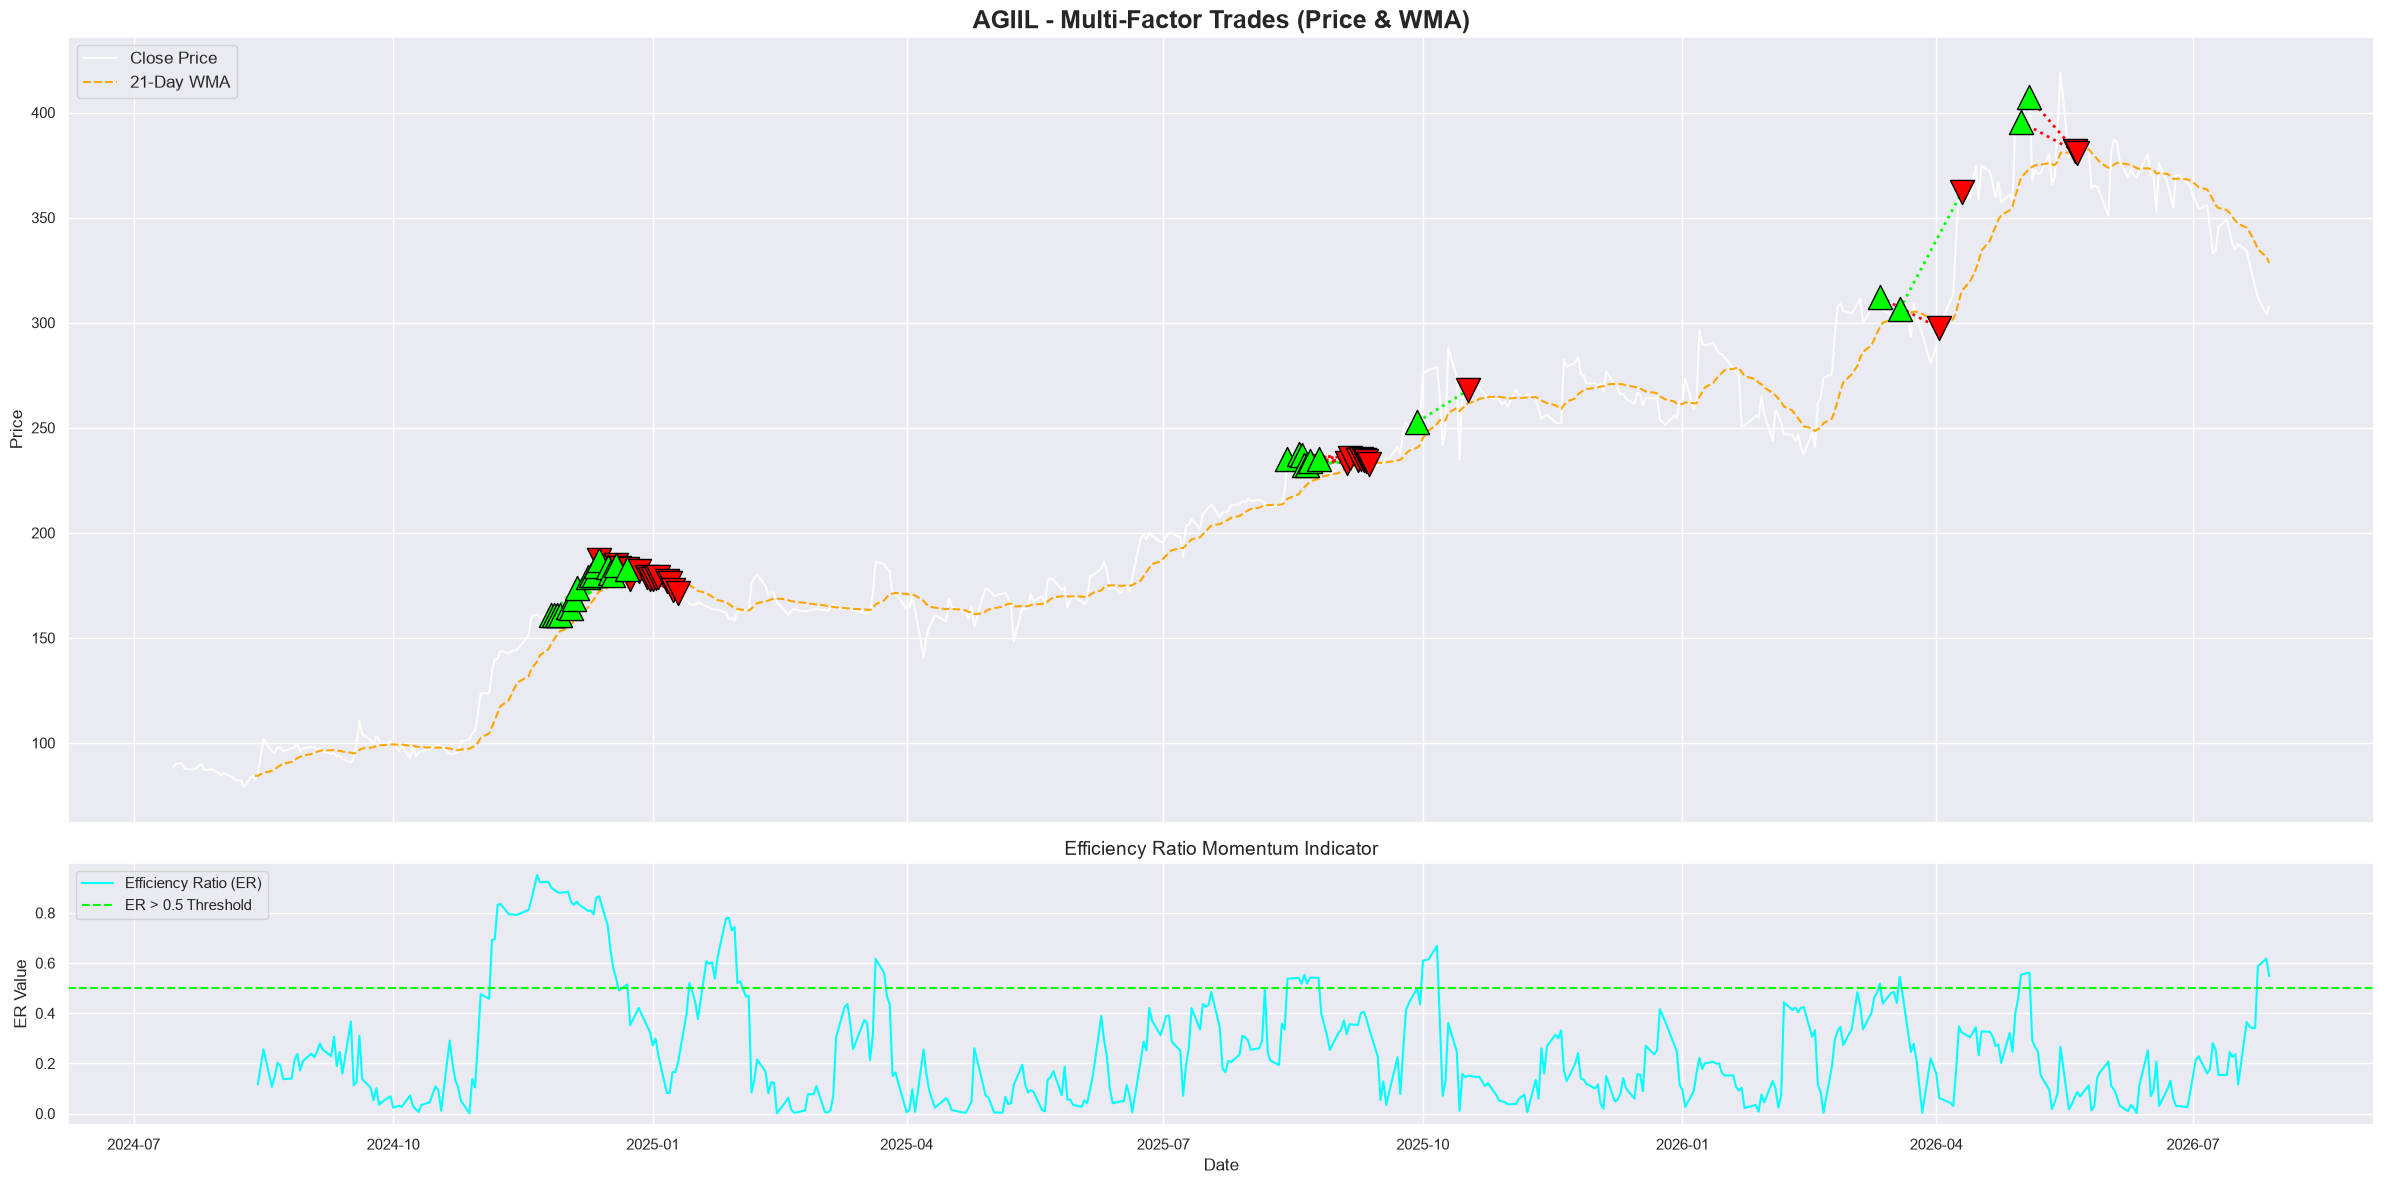

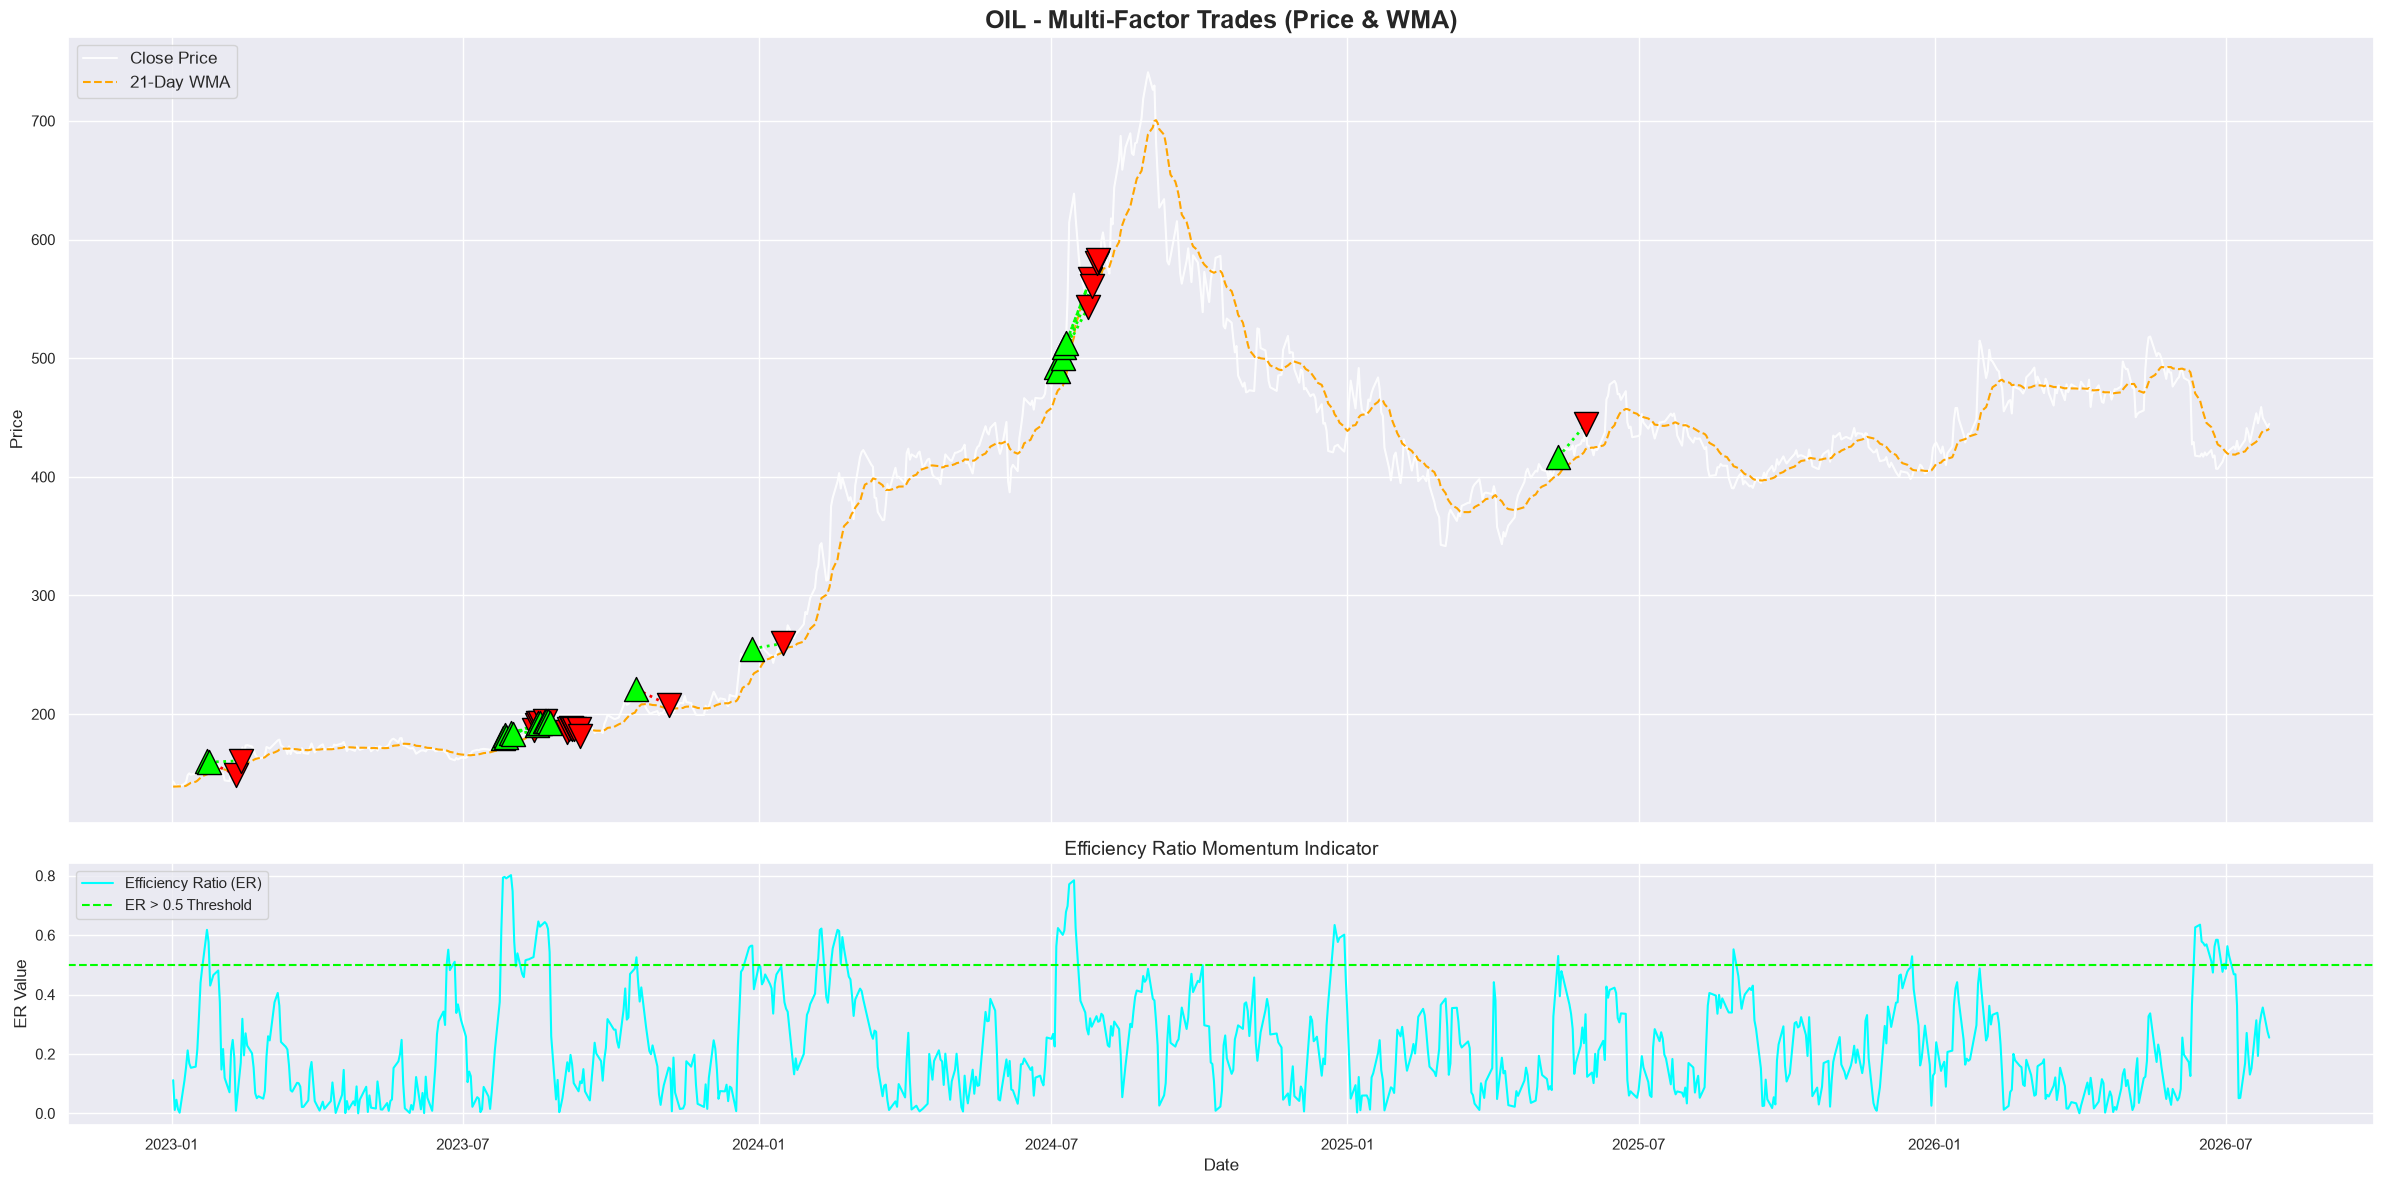

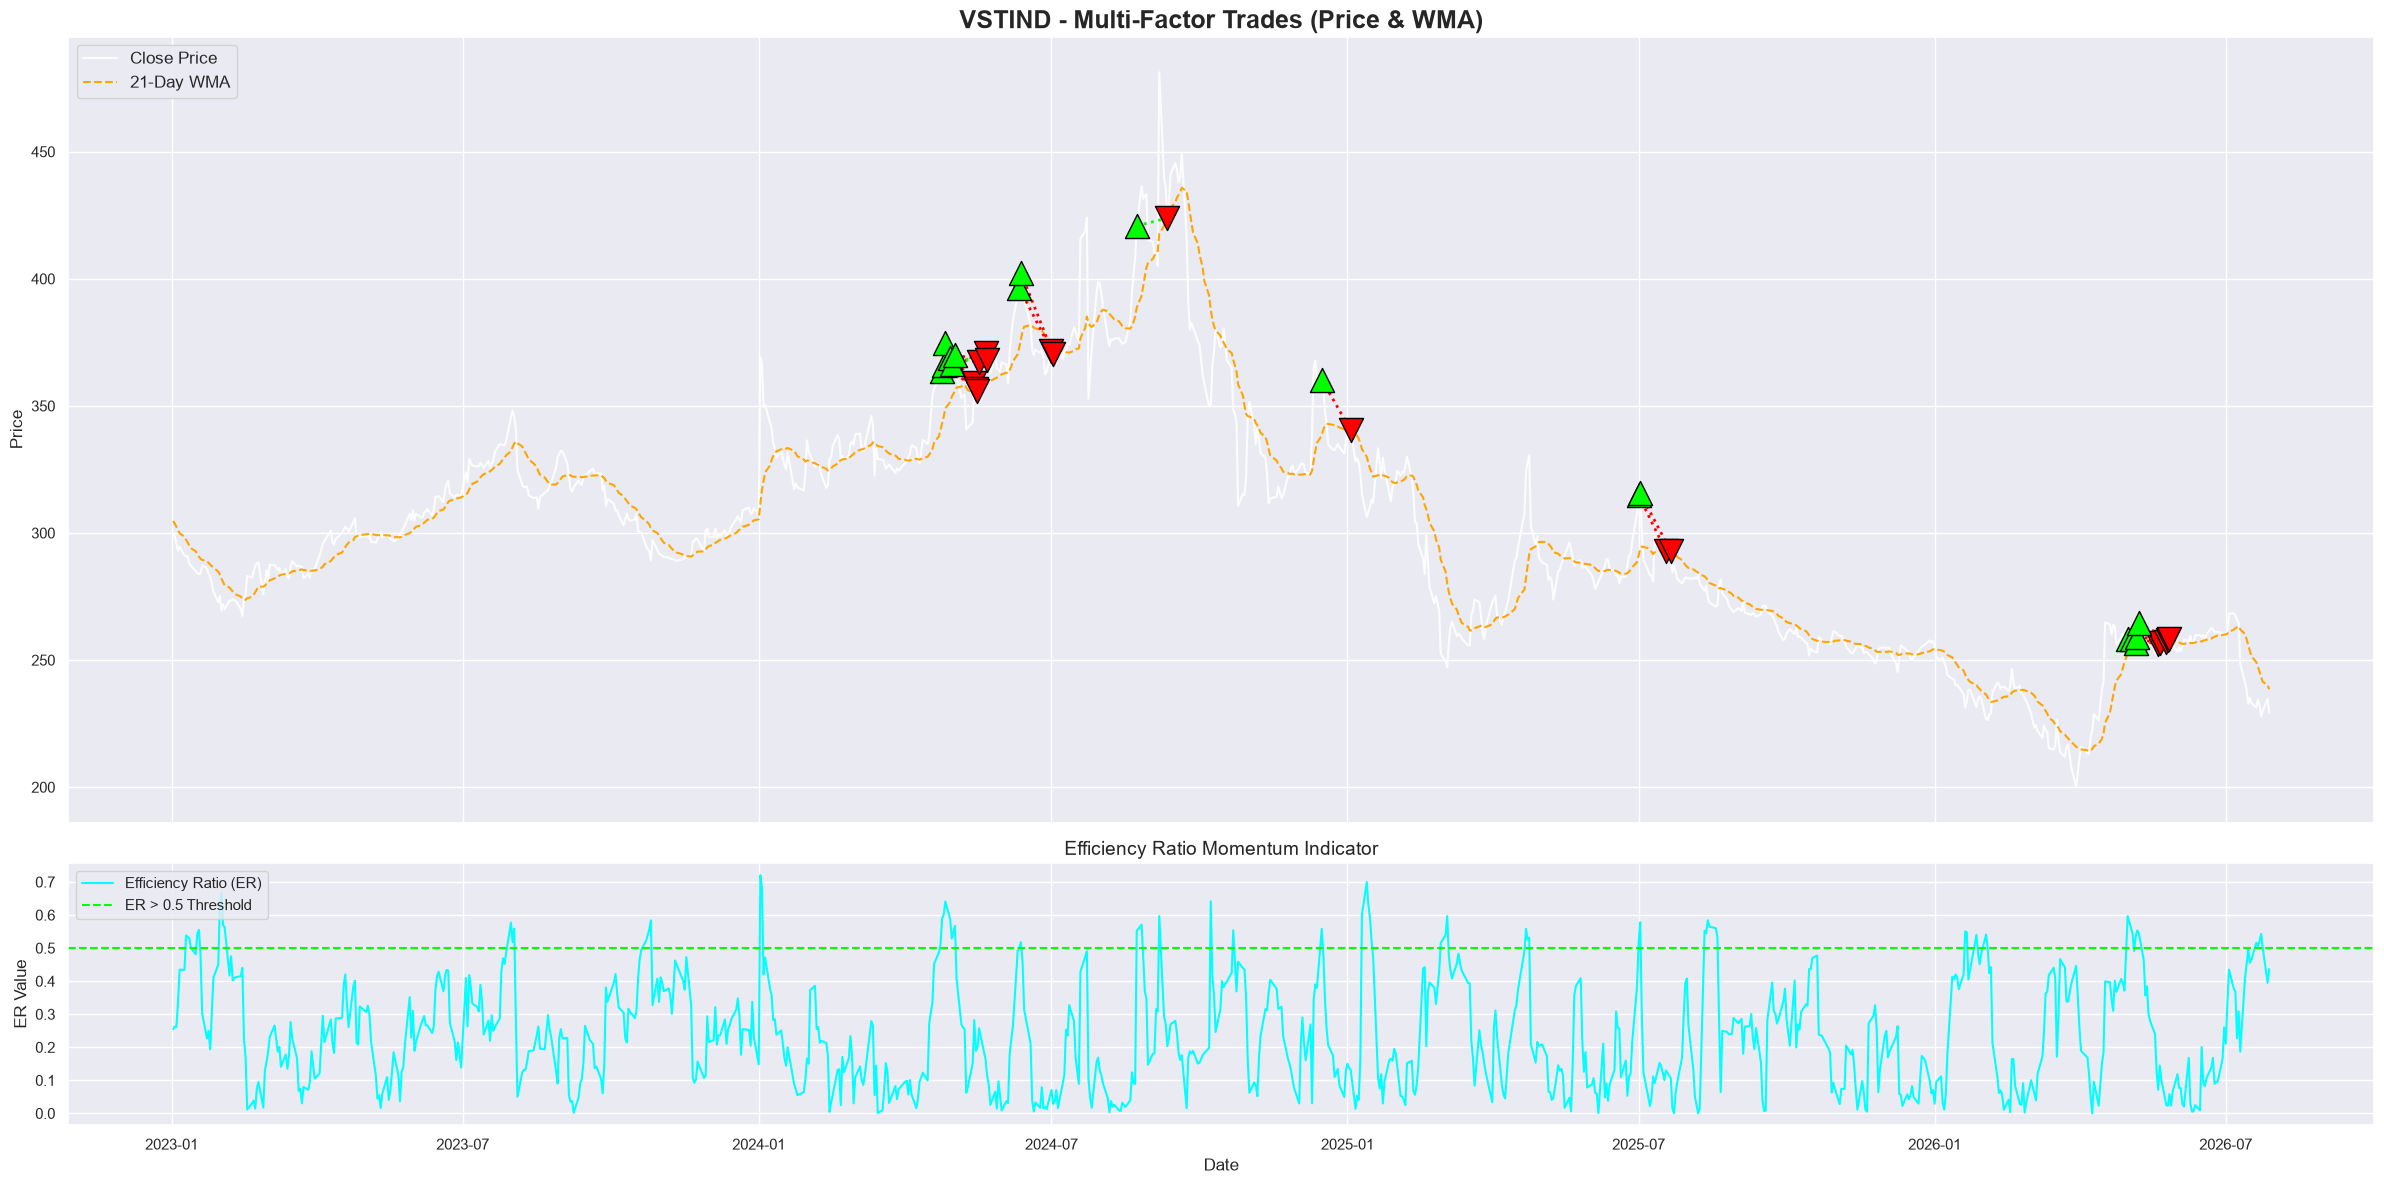

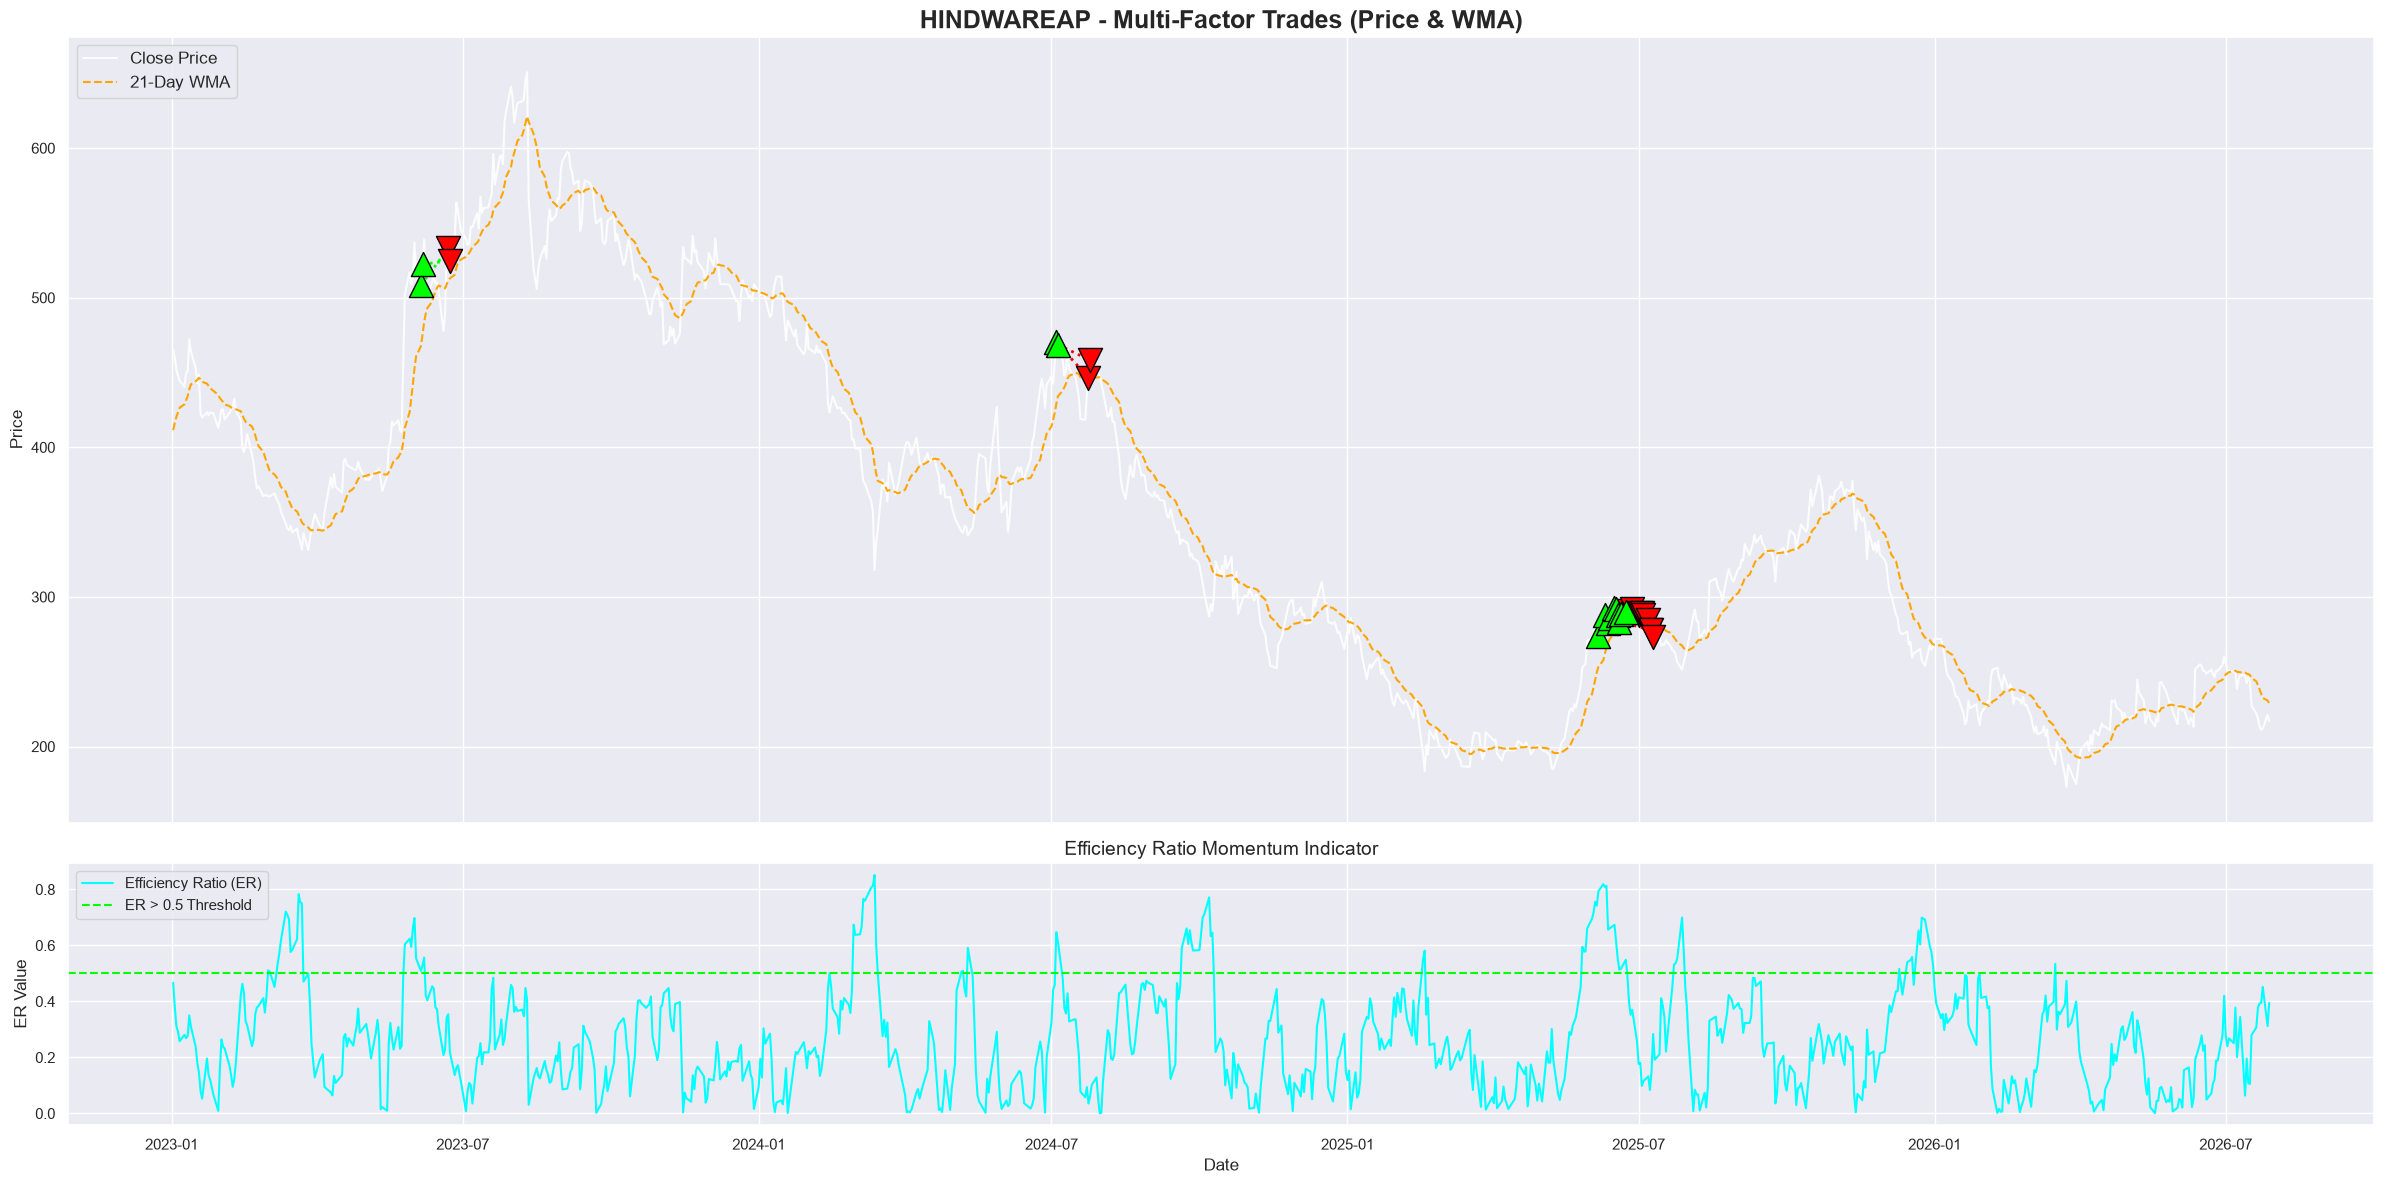

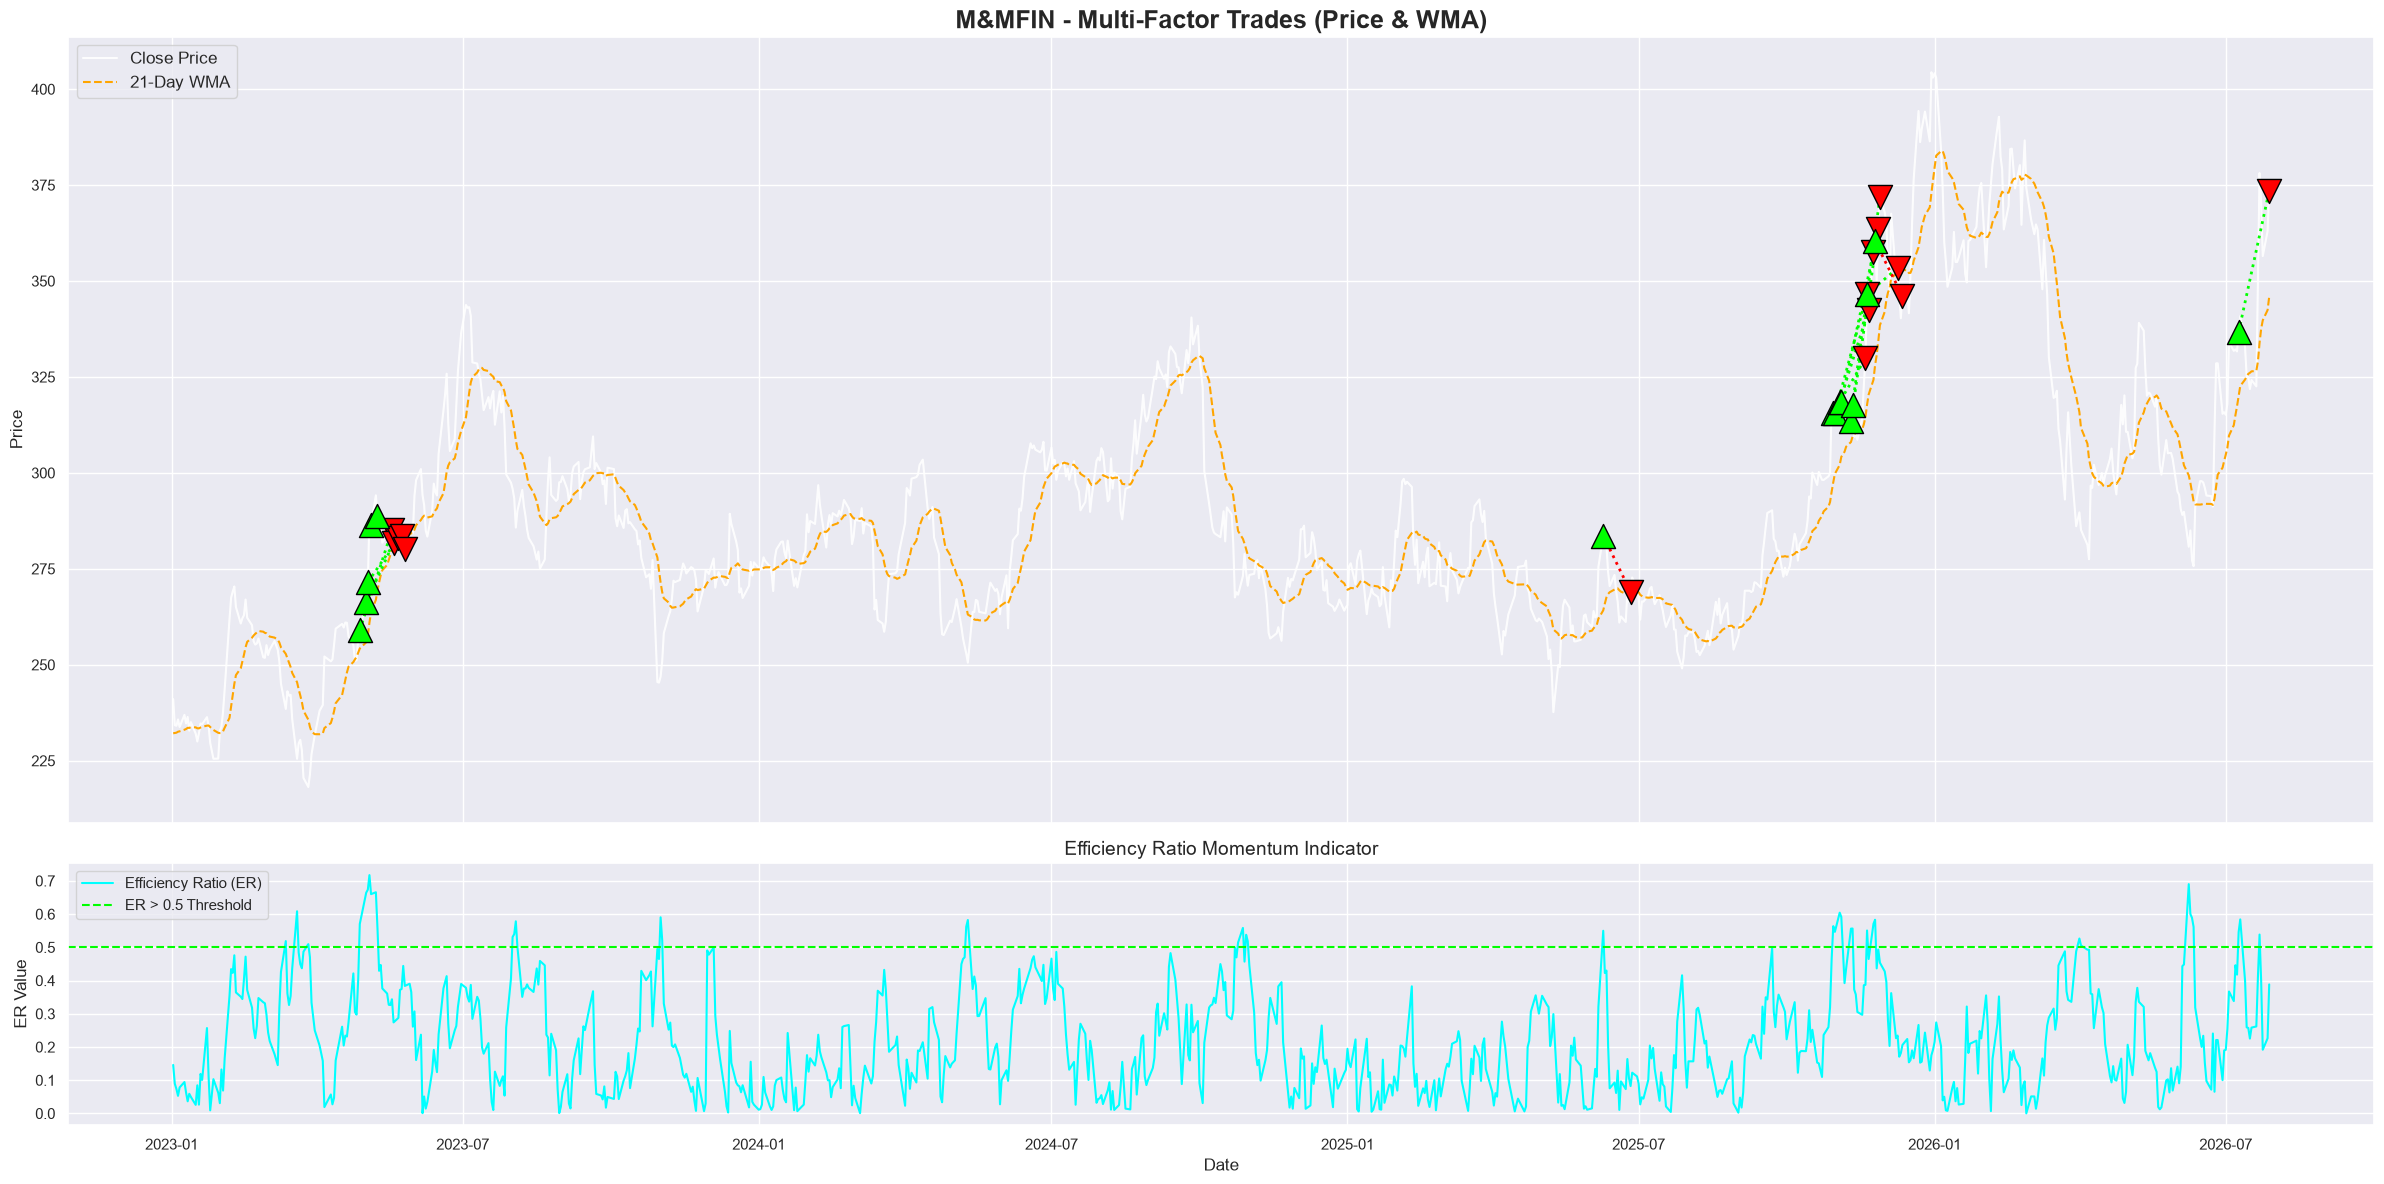

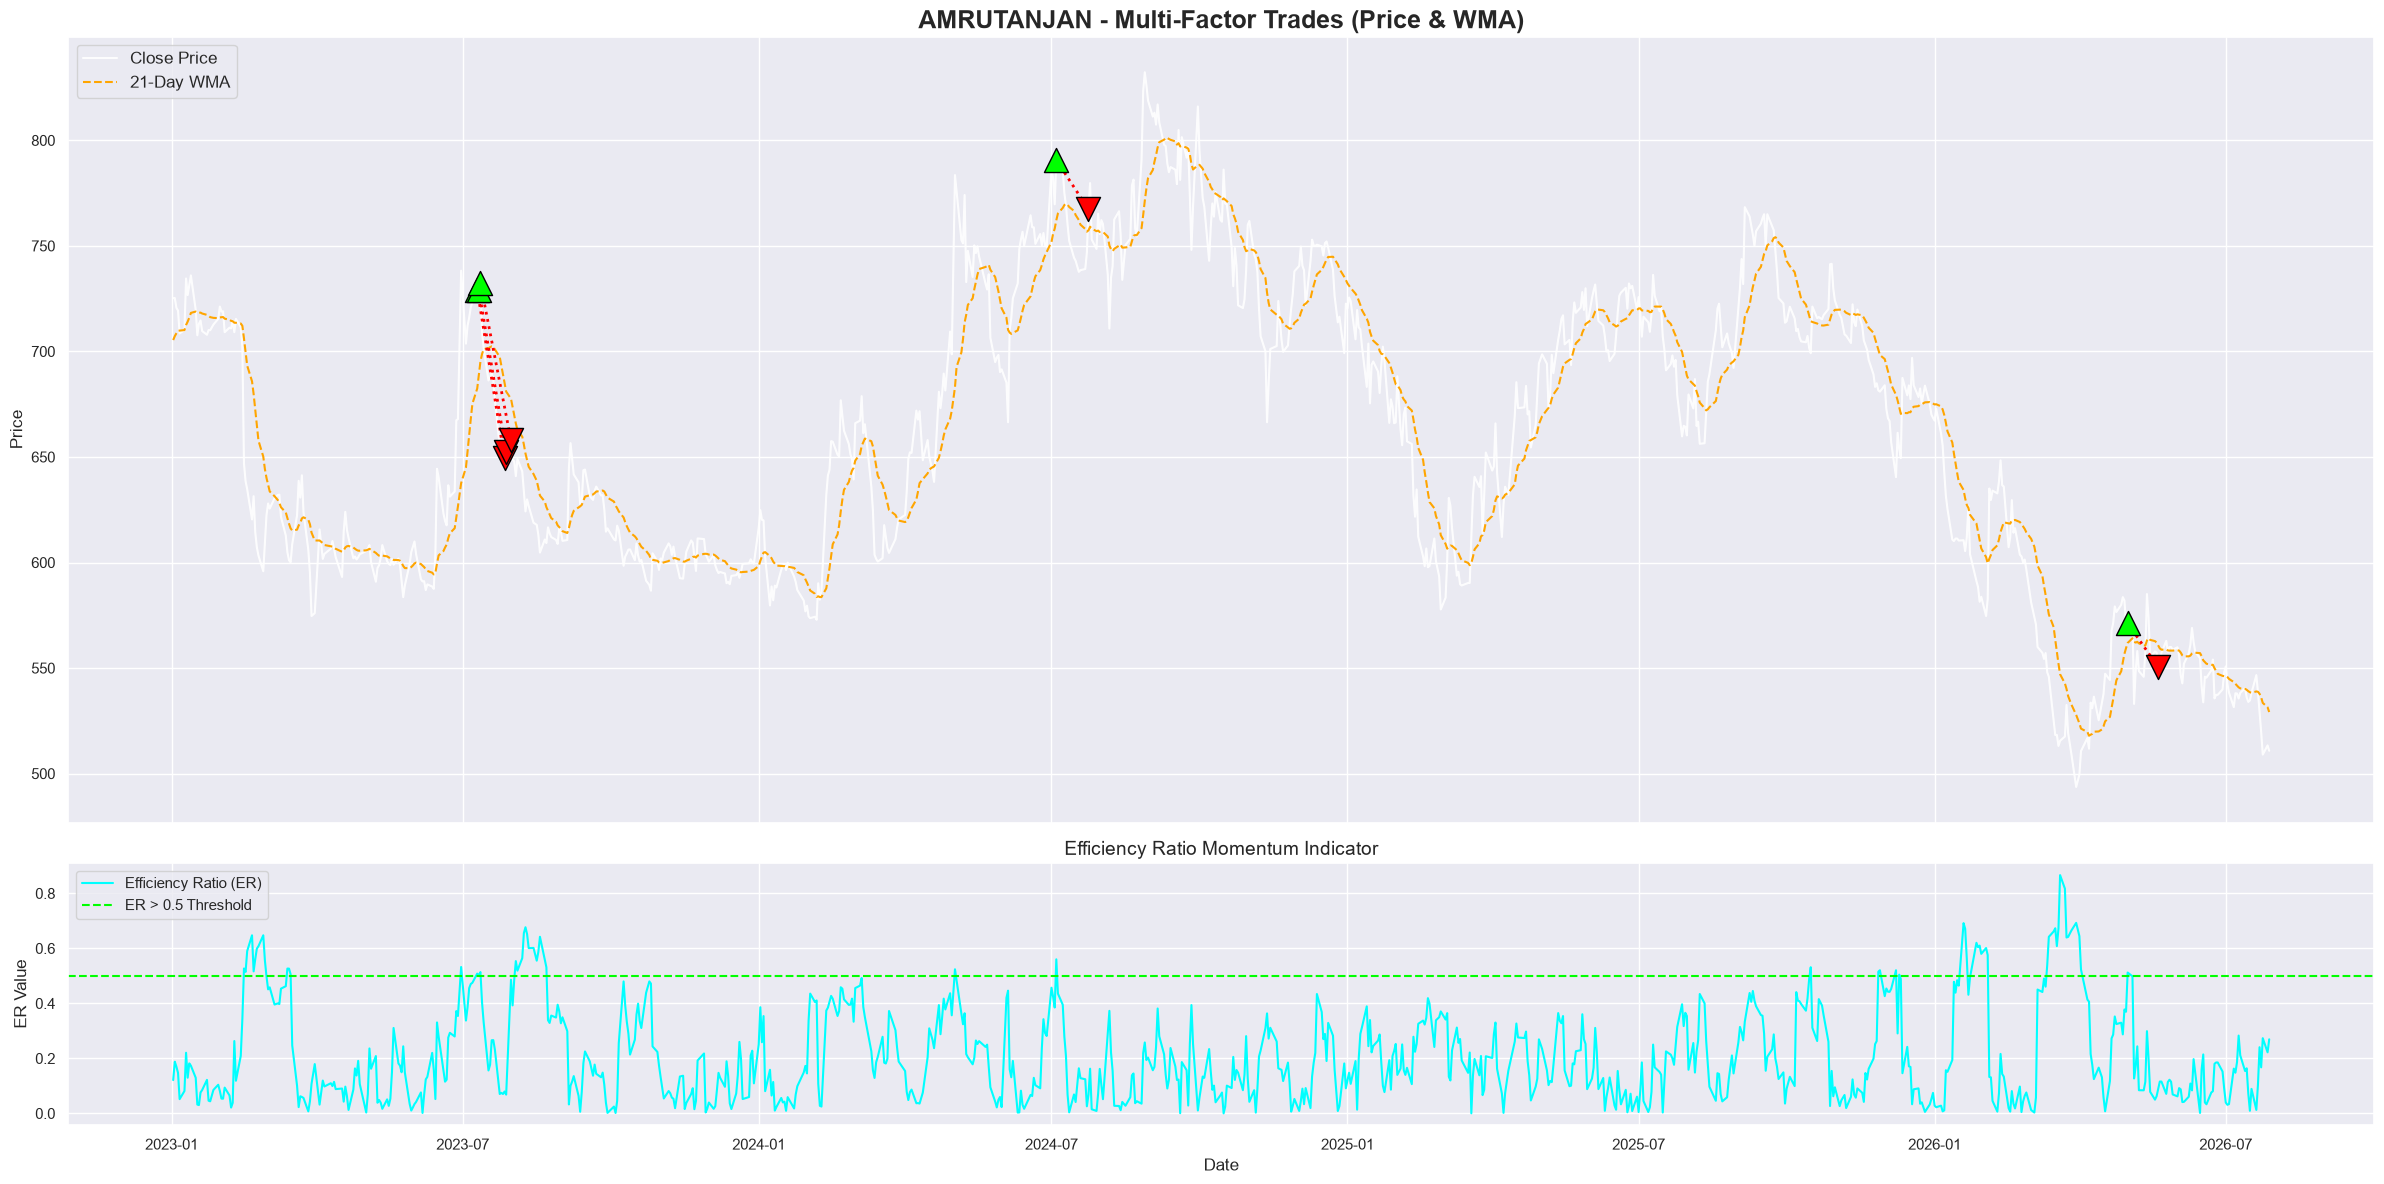

In [4]:
# 4. Plotting Loop (Price + WMA + Entries/Exits + ER)
for symbol in trade_symbols:
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    stock_trades = trades[trades['Symbol'] == symbol]
    
    # Create subplots: 2 rows, 1 column, shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 12), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    # --- Top Subplot: Price, WMA, Entries, Exits ---
    ax1.plot(df['Date'], df['Close'], label='Close Price', color='white', linewidth=1.5, alpha=0.9)
    ax1.plot(df['Date'], df['WMA'], label=f'{LOOKBACK}-Day WMA', color='orange', linewidth=1.5, linestyle='--')
    
    # Plot Trades
    for idx, trade in stock_trades.iterrows():
        entry_date = trade['Date']
        entry_price = trade['Close']
        
        # Find exact exit index
        entry_idx = df[df['Date'] == entry_date].index[0]
        exit_idx = entry_idx + HOLD_DAYS
        
        if exit_idx < len(df):
            exit_date = df.loc[exit_idx, 'Date']
            exit_price = df.loc[exit_idx, 'Close']
            
            # Entry Marker (Green Up Arrow)
            ax1.scatter(entry_date, entry_price, color='lime', marker='^', s=300, zorder=5, edgecolors='black')
            # Exit Marker (Red Down Arrow)
            ax1.scatter(exit_date, exit_price, color='red', marker='v', s=300, zorder=5, edgecolors='black')
            
            # Draw a dotted line connecting Entry to Exit
            color = 'lime' if exit_price > entry_price else 'red'
            ax1.plot([entry_date, exit_date], [entry_price, exit_price], color=color, linestyle=':', linewidth=2)
            
    ax1.set_title(f"{symbol} - Multi-Factor Trades (Price & WMA)", fontsize=18, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=12)
    ax1.set_ylabel('Price')
    
    # --- Bottom Subplot: Efficiency Ratio ---
    ax2.plot(df['Date'], df['ER'], color='cyan', linewidth=1.5, label='Efficiency Ratio (ER)')
    ax2.axhline(y=0.5, color='lime', linestyle='--', linewidth=1.5, label='ER > 0.5 Threshold')
    ax2.set_title('Efficiency Ratio Momentum Indicator', fontsize=14)
    ax2.set_ylabel('ER Value')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
